# Campaign property trends

Manual, read-only exploration of every `data/results/begins_*/agg.csv`. Each marker is a sample mean and each error bar is **±1 intra-sample standard deviation**. Actual raw specimen timestamps are used when available; processing timestamps are the fallback.

Run the cells from top to bottom. Edit only the settings cell for normal use.

In [49]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Works whether Jupyter starts in the repository root or EVALUATE/.
repo_root = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
evaluate_dir = repo_root / 'EVALUATE'
if str(evaluate_dir) not in sys.path:
    sys.path.insert(0, str(evaluate_dir))

from campaign_trends import (
    available_properties, export_campaign, load_campaign_data,
    plot_properties, select_campaign,
)

## Settings

In [50]:
PROPERTIES = [
    'Thickness',
    'Elastic Modulus',
    'Yield Strength',
    'Pore Fraction',
    'Creep Strain',
    'Strain at 50 bar',
]
PROPERTY_UNITS = {
    'Thickness': 'µm',
    'Elastic Modulus': 'bar',
    'Yield Strength': 'bar',
    'Pore Fraction': 'dimensionless',
    'Creep Strain': 'dimensionless',
    'Strain at 50 bar': 'dimensionless',
    'Strain at 80 bar': 'dimensionless',
    'Strain at 150 bar': 'dimensionless',
    'Strain at 500 bar': 'dimensionless',
    'Slope Plateau': 'bar',
    'Slope Densification': 'bar',
    'CV': 'dimensionless',
}

def property_label(property_name):
    unit = PROPERTY_UNITS.get(property_name)
    return f'{property_name} ({unit})' if unit and unit != 'dimensionless' else property_name
START = None       # Example: '2026-08-10'
END = None         # Example: '2026-08-22' (the full day is included)
CAMPAIGNS = None   # Example: ['2026-08-20-exploration-mode']; None means all
CONNECT_POINTS = True
SAVE_OUTPUTS = False
CHEMISTRY_FILTER = 'Polysulfone / PolarClean (inferred)'  # Set to None for every chemistry

## Campaign interpretation

The dated `llm.csv` suggestions identify the campaign intent as follows:

- **Aug 11–20 afternoon:** directed mechanical optimization. The suggestions repeatedly state the primary objective is to maximize Elastic Modulus and the secondary objective is to minimize Strain at 50 bar. The 17 wt%, additive-free formulation is treated as Polysulfone/PolarClean.
- **From Aug 20 exploration-mode onward:** deliberate design-space exploration. The LLM suggestions explicitly prioritize sparse-region coverage, while retaining modulus/strain as downstream objectives.

These labels are campaign-level interpretations, not analytical identification of the chemicals. Change `PHASES` below if laboratory records provide more exact boundaries. Dashed lines are the running best achieved value: upper envelope for maximization and lower envelope for minimization.

In [51]:
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Boundaries inferred from the dated LLM suggestions. None means extend to plot edge.
PHASES = [
    dict(start=None, end='2026-08-20 16:30',
         label='Polysulfone / PolarClean\nmaximize modulus; minimize strain', color='#7fc8a9'),
    dict(start='2026-08-20 16:30', end=None,
         label='Polysulfone / PolarClean\nexplorative design-space coverage', color='#91b7e8'),
]

# Direction is based on the objectives stated in the LLM suggestions. Add/edit as needed.
GOAL_DIRECTION = {
    'Elastic Modulus': 'maximize',
    'Yield Strength': 'maximize',
    'Strain at 50 bar': 'minimize',
    'Strain at 80 bar': 'minimize',
    'Strain at 150 bar': 'minimize',
    'Strain at 500 bar': 'minimize',
}

def infer_chemistry(row):
    """Notebook-only heuristic supplied with the campaign context."""
    polymer = pd.to_numeric(row.get('polymer_wt'), errors='coerce')
    additive = pd.to_numeric(row.get('additive_wt'), errors='coerce')
    name = str(row.get('condition', ''))
    if (pd.notna(polymer) and polymer >= 20 and pd.notna(additive) and additive > 0) or (name.startswith('21-') and not name.startswith('21-0add')):
        return 'Primospire / NMP + PVP (inferred)'
    if (pd.notna(polymer) and polymer >= 20) or name.startswith('21-'):
        return 'Primospire / NMP, no PVP (inferred)'
    if pd.notna(polymer) and polymer <= 17:
        return 'Polysulfone / PolarClean (inferred)'
    return 'Unclassified formulation'

def _shade_phases(ax, points):
    for phase in PHASES:
        mask = pd.Series(True, index=points.index)
        if phase['start'] is not None:
            mask &= points['sample_time'] >= pd.Timestamp(phase['start'])
        if phase['end'] is not None:
            mask &= points['sample_time'] < pd.Timestamp(phase['end'])
        phase_iterations = points.loc[mask, 'iteration']
        if not phase_iterations.empty:
            ax.axvspan(phase_iterations.min() - 0.5, phase_iterations.max() + 0.5,
                       color=phase['color'], alpha=0.18, zorder=0)

def plot_detailed_campaign(data, properties, color_column, color_label, *,
                           nitrogen_markers=False, columns=2, connect_points=True, cmap='viridis'):
    """Plot one campaign view with a selectable color variable and fixed marker size."""
    import math
    properties = list(properties)
    columns = max(1, min(columns, len(properties)))
    rows = math.ceil(len(properties) / columns)
    fig, grid = plt.subplots(rows, columns, figsize=(8.5 * columns, 5.2 * rows), squeeze=False)
    axes = list(grid.flat)
    valid_times = data['sample_time'].dropna()
    minimum_time, maximum_time = valid_times.min(), valid_times.max()
    enriched = data.copy()
    enriched['chemistry'] = enriched.apply(infer_chemistry, axis=1)
    enriched = enriched.sort_values('sample_time').reset_index(drop=True)
    enriched['iteration'] = enriched.index + 1
    color_values = pd.to_numeric(enriched[color_column], errors='coerce')
    color_min, color_max = color_values.min(), color_values.max()
    if color_min == color_max:
        color_min -= 0.5
        color_max += 0.5
    normalization = plt.Normalize(color_min, color_max)
    color_map = plt.get_cmap(cmap)
    def nitrogen_is_on(value):
        return value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}
    for ax, prop in zip(axes, properties):
        mean_col, sd_col = f'{prop} Mean', f'{prop} SD'
        points = enriched.dropna(subset=['sample_time', mean_col]).sort_values('sample_time')
        _shade_phases(ax, enriched)
        if connect_points:
            ax.plot(points['iteration'], points[mean_col], color='#707070', lw=0.9, alpha=0.55, zorder=2)
        point_color_values = pd.to_numeric(points[color_column], errors='coerce').fillna(color_values.median())
        point_colors = color_map(normalization(point_color_values))
        for (_, point), color in zip(points.iterrows(), point_colors):
            error = pd.to_numeric(pd.Series([point.get(sd_col)]), errors='coerce').fillna(0).iloc[0]
            marker = ('o' if nitrogen_is_on(point.get('nitrogen')) else 's') if nitrogen_markers else 'o'
            ax.errorbar(point['iteration'], point[mean_col], yerr=error,
                        fmt=marker, linestyle='none', color=color, ecolor=color,
                        markeredgecolor='black', markeredgewidth=1.2,
                        markersize=11, capsize=4, elinewidth=1.3, zorder=3)
        direction = GOAL_DIRECTION.get(prop)
        if direction:
            values = pd.to_numeric(points[mean_col], errors='coerce')
            running_best = values.cummax() if direction == 'maximize' else values.cummin()
            ax.step(points['iteration'], running_best, where='post', color='#b21f35',
                    linestyle='--', linewidth=1.6,
                    label=f'Running best ({direction})', zorder=4)
        ax.set_title(prop, fontsize=20, fontweight='semibold', pad=12)
        ax.set_xlabel('Iteration (chronological order)', fontsize=16, labelpad=9)
        ax.set_ylabel(f'{property_label(prop)} (mean ± SD)', fontsize=13, labelpad=8)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.label.set_size(16)
        ax.grid(True, alpha=0.22)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_xlim(0.5, len(enriched) + 0.5)
    for ax in axes[len(properties):]:
        ax.remove()
    phase_handles = [Patch(facecolor=p['color'], alpha=.25, label=p['label']) for p in PHASES]
    goal_handle = plt.Line2D([], [], color='#b21f35', linestyle='--', label='Optimization goal: running best')
    nitrogen_handles = [
        plt.Line2D([], [], marker='o', markersize=13, markerfacecolor='#888888', markeredgecolor='black', linestyle='none', label='Nitrogen on'),
        plt.Line2D([], [], marker='s', markersize=13, markerfacecolor='#888888', markeredgecolor='black', linestyle='none', label='Nitrogen off'),
    ]
    legend_handles = phase_handles + [goal_handle] + (nitrogen_handles if nitrogen_markers else [])
    fig.legend(handles=legend_handles,
               loc='lower center', bbox_to_anchor=(0.5, 0.12),
               ncol=4, frameon=False, fontsize=13, labelspacing=1.0, columnspacing=1.5)
    color_scale = plt.cm.ScalarMappable(norm=normalization, cmap=color_map)
    color_scale.set_array([])
    # A dedicated axis keeps the color scale clear of the right-hand plots.
    fig.subplots_adjust(left=0.09, right=0.87, bottom=0.25, top=0.90, wspace=0.32, hspace=0.42)
    colorbar_axis = fig.add_axes([0.915, 0.25, 0.018, 0.55])
    colorbar = fig.colorbar(color_scale, cax=colorbar_axis)
    colorbar.set_label(color_label, fontsize=16, labelpad=14)
    colorbar.ax.tick_params(labelsize=14)
    fig.suptitle(f'Polysulfone / PolarClean properties — color: {color_label}',
                 fontsize=22, fontweight='semibold')
    return fig, axes[:len(properties)], enriched

In [52]:
all_data = load_campaign_data(repo_root / 'data' / 'results', repo_root / 'data' / 'raw')
campaign = select_campaign(all_data, start=START, end=END, campaigns=CAMPAIGNS)
campaign['chemistry'] = campaign.apply(infer_chemistry, axis=1)
if CHEMISTRY_FILTER is not None:
    campaign = campaign[campaign['chemistry'] == CHEMISTRY_FILTER].copy()
property_mean_columns = [f'{prop} Mean' for prop in PROPERTIES]
campaign = campaign[campaign[property_mean_columns].notna().any(axis=1)].copy()
campaign = campaign[pd.to_numeric(campaign['Thickness Mean'], errors='coerce') >= 70].copy()
# Remove the incomplete 10 wt% baseline; the retained PolarClean campaign spans 13–17 wt%.
campaign = campaign[pd.to_numeric(campaign['polymer_wt'], errors='coerce') >= 13].copy()
# Drop artifacts with negative mean strain at 50 bar.
strain_50 = pd.to_numeric(campaign['Strain at 50 bar Mean'], errors='coerce')
campaign = campaign[~(strain_50 < 0)].copy()
# Split exposure into state-specific durations so nitrogen-on and nitrogen-off slopes can differ.
campaign['nitrogen_binary'] = campaign['nitrogen'].map(
    lambda value: 1 if (value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}) else 0
)
campaign['nitrogen_exposure_time'] = campaign['coupon_to_bath_wait_time'] * campaign['nitrogen_binary']
campaign['air_exposure_time'] = campaign['coupon_to_bath_wait_time'] * (1 - campaign['nitrogen_binary'])
print(f'{len(campaign)} samples from {campaign.sample_time.min()} to {campaign.sample_time.max()}')
print('Available properties:', available_properties(campaign))
campaign[['sample_time', 'condition', 'campaign', 'chemistry', 'time_source']].head()

66 samples from 2026-08-14 19:51:41 to 2026-09-09 10:25:25
Available properties: ['Creep Strain', 'Elastic Modulus', 'Pore Fraction', 'Slope Densification', 'Slope Plateau', 'Strain at 150 bar', 'Strain at 50 bar', 'Strain at 500 bar', 'Strain at 80 bar', 'Thickness', 'Yield Strength']


,sample_time,condition,campaign,chemistry,time_source
14,2026-08-14 19:51:41,17-0add-5deg-30s-N2-125s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
15,2026-08-14 20:39:10,17-0add-5deg-60s-N2-1800s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
16,2026-08-14 21:55:19,17-0add-5deg-90s-N2-1800s_run2,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
17,2026-08-14 23:14:19,17-0add-5deg-120s-N2-1800s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
18,2026-08-15 00:32:14,17-0add-5deg-90s-N2-1800s_run3,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename


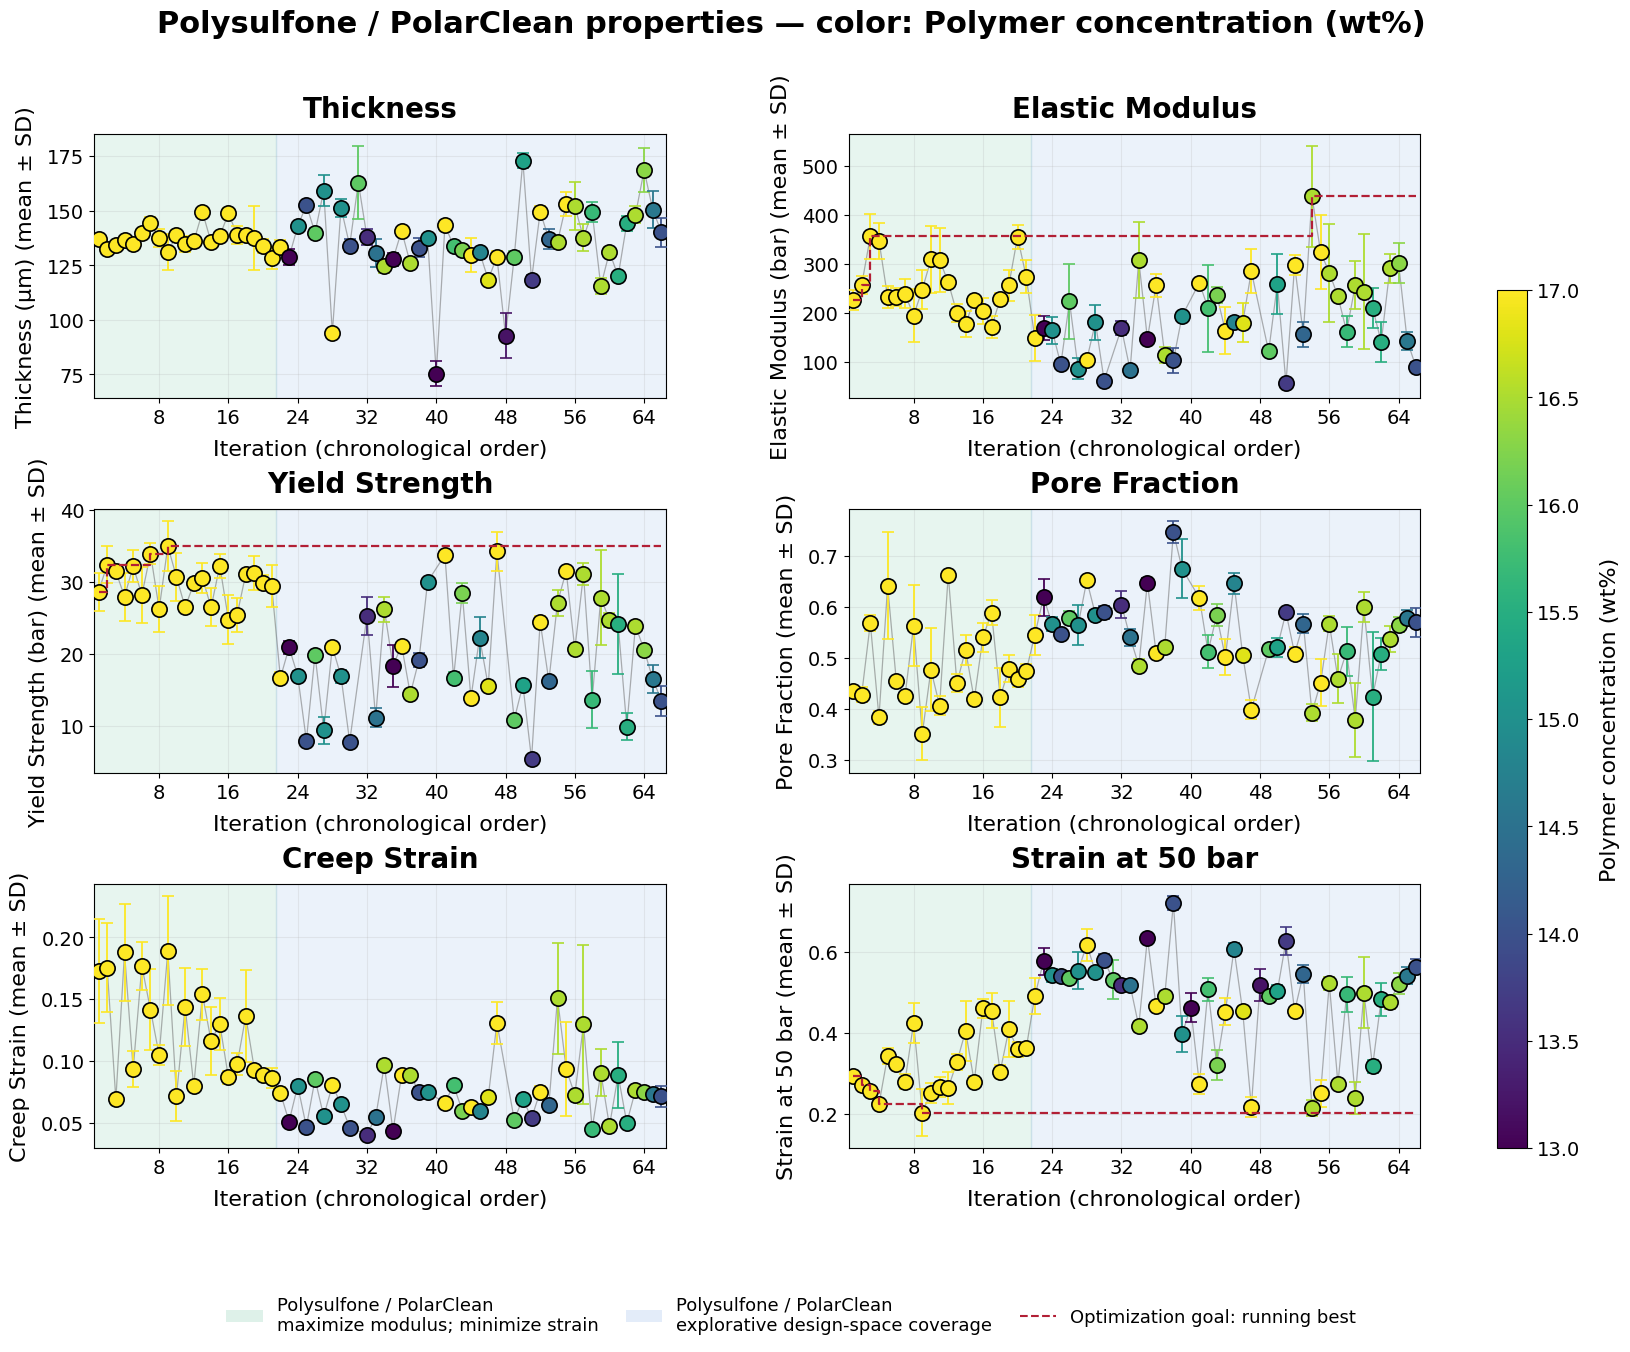

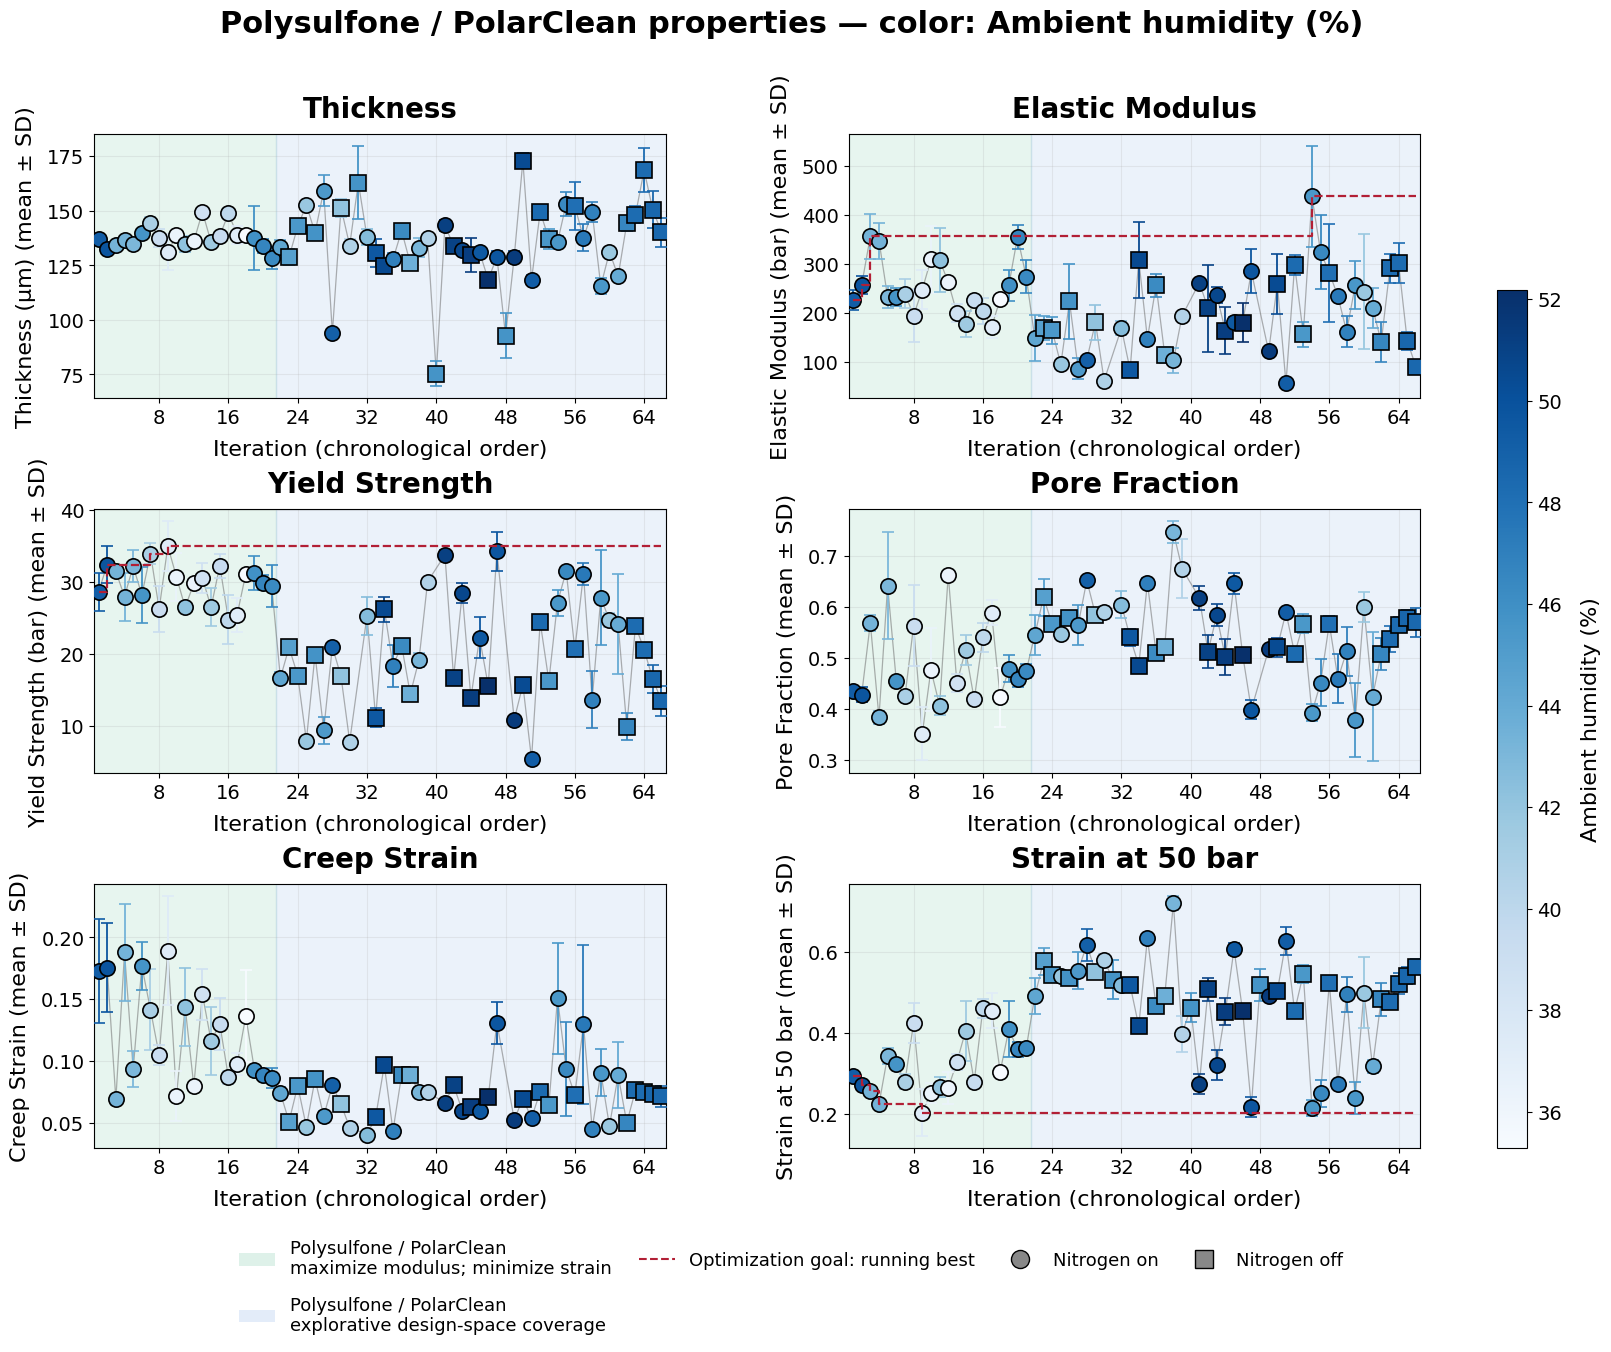

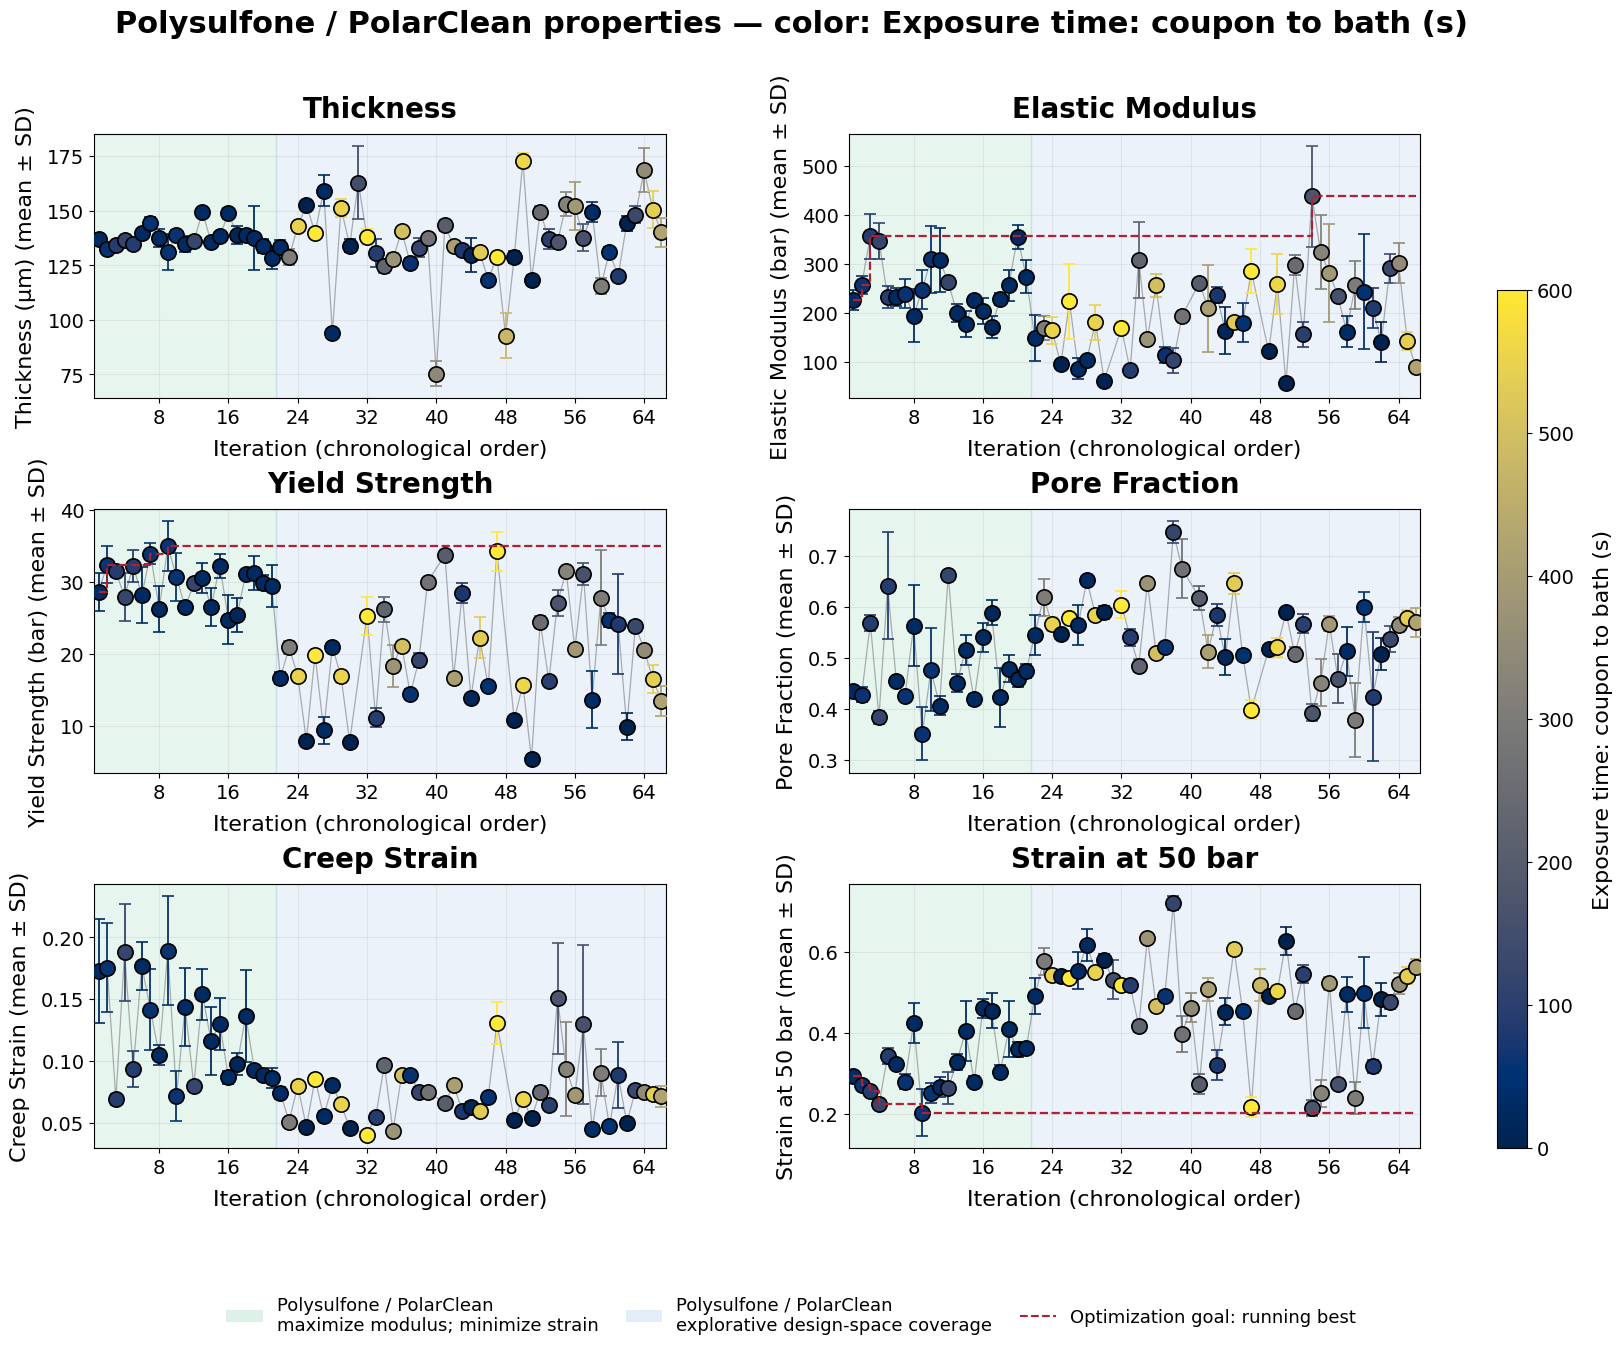

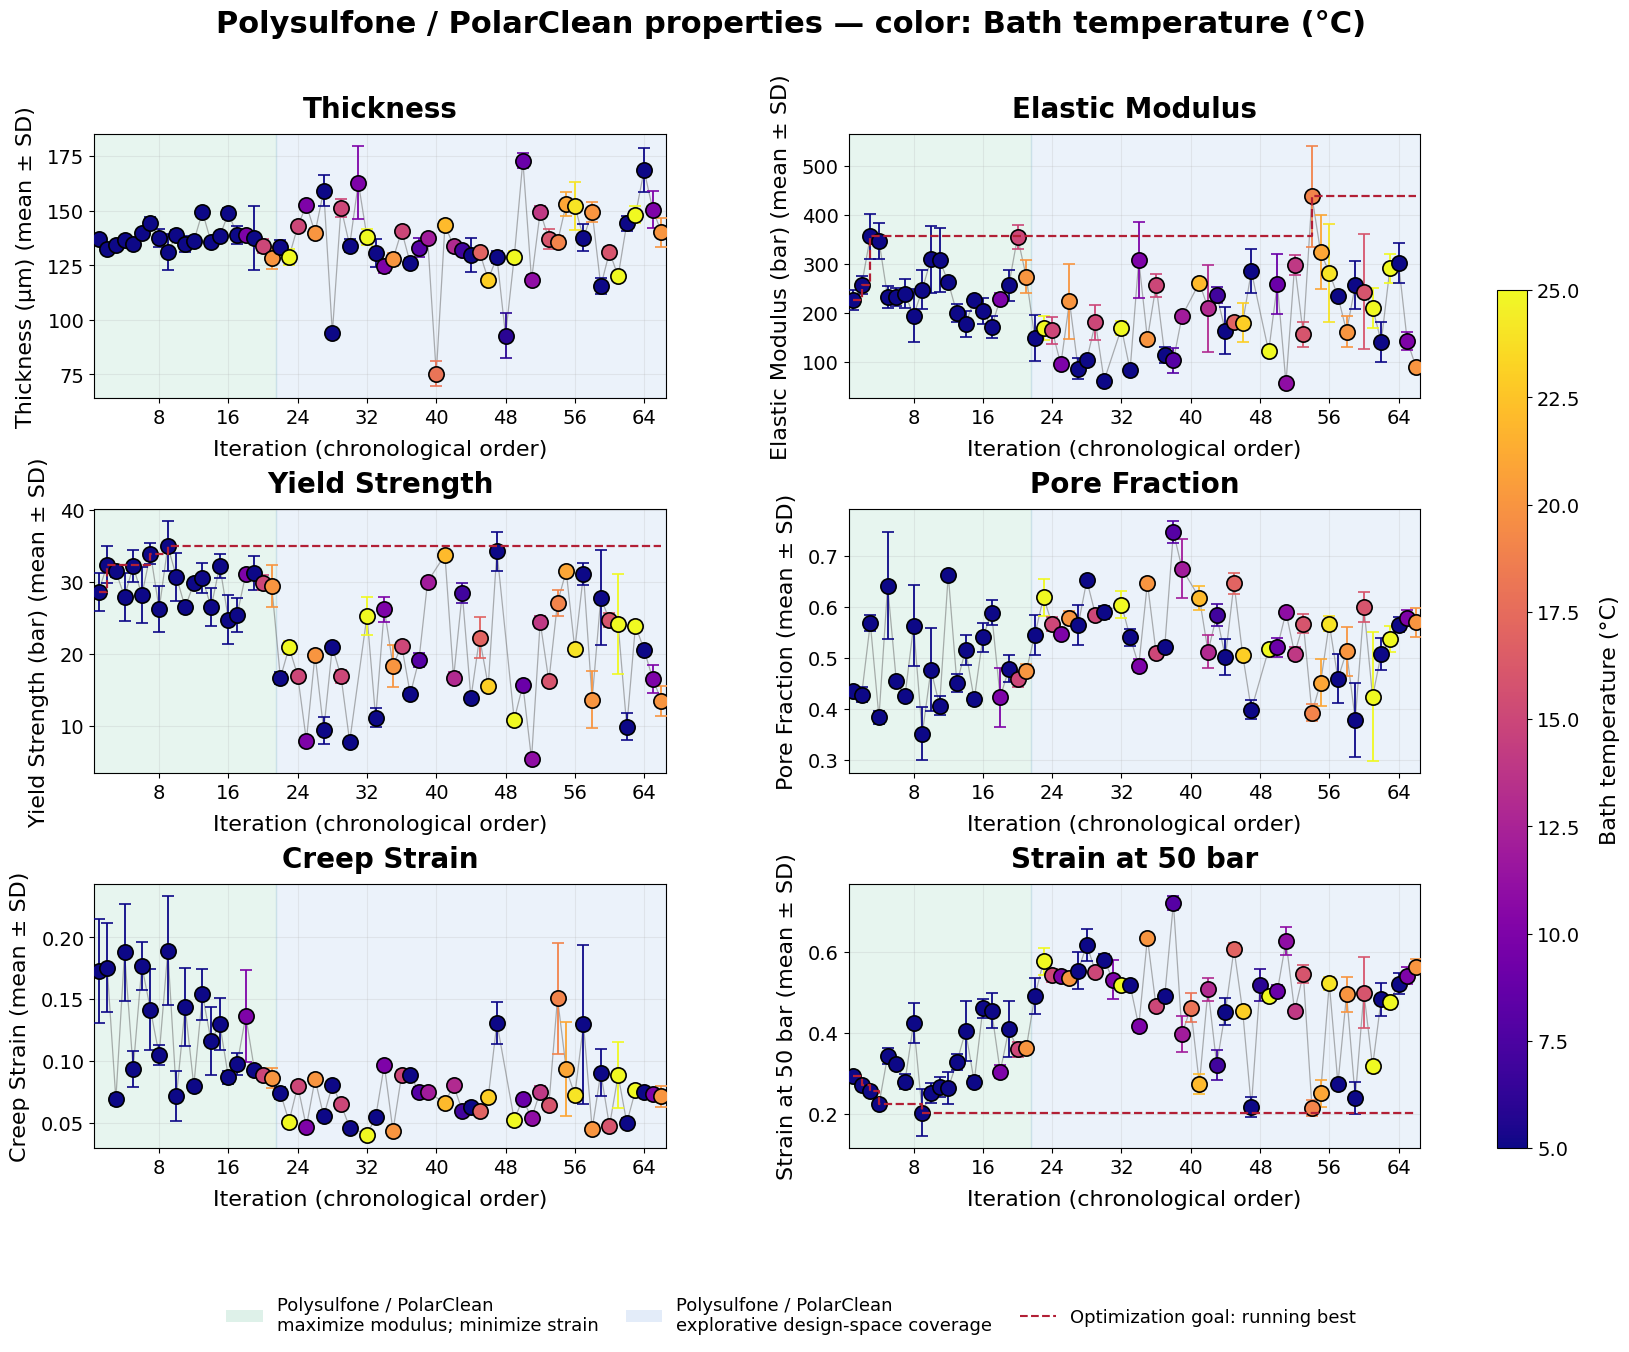

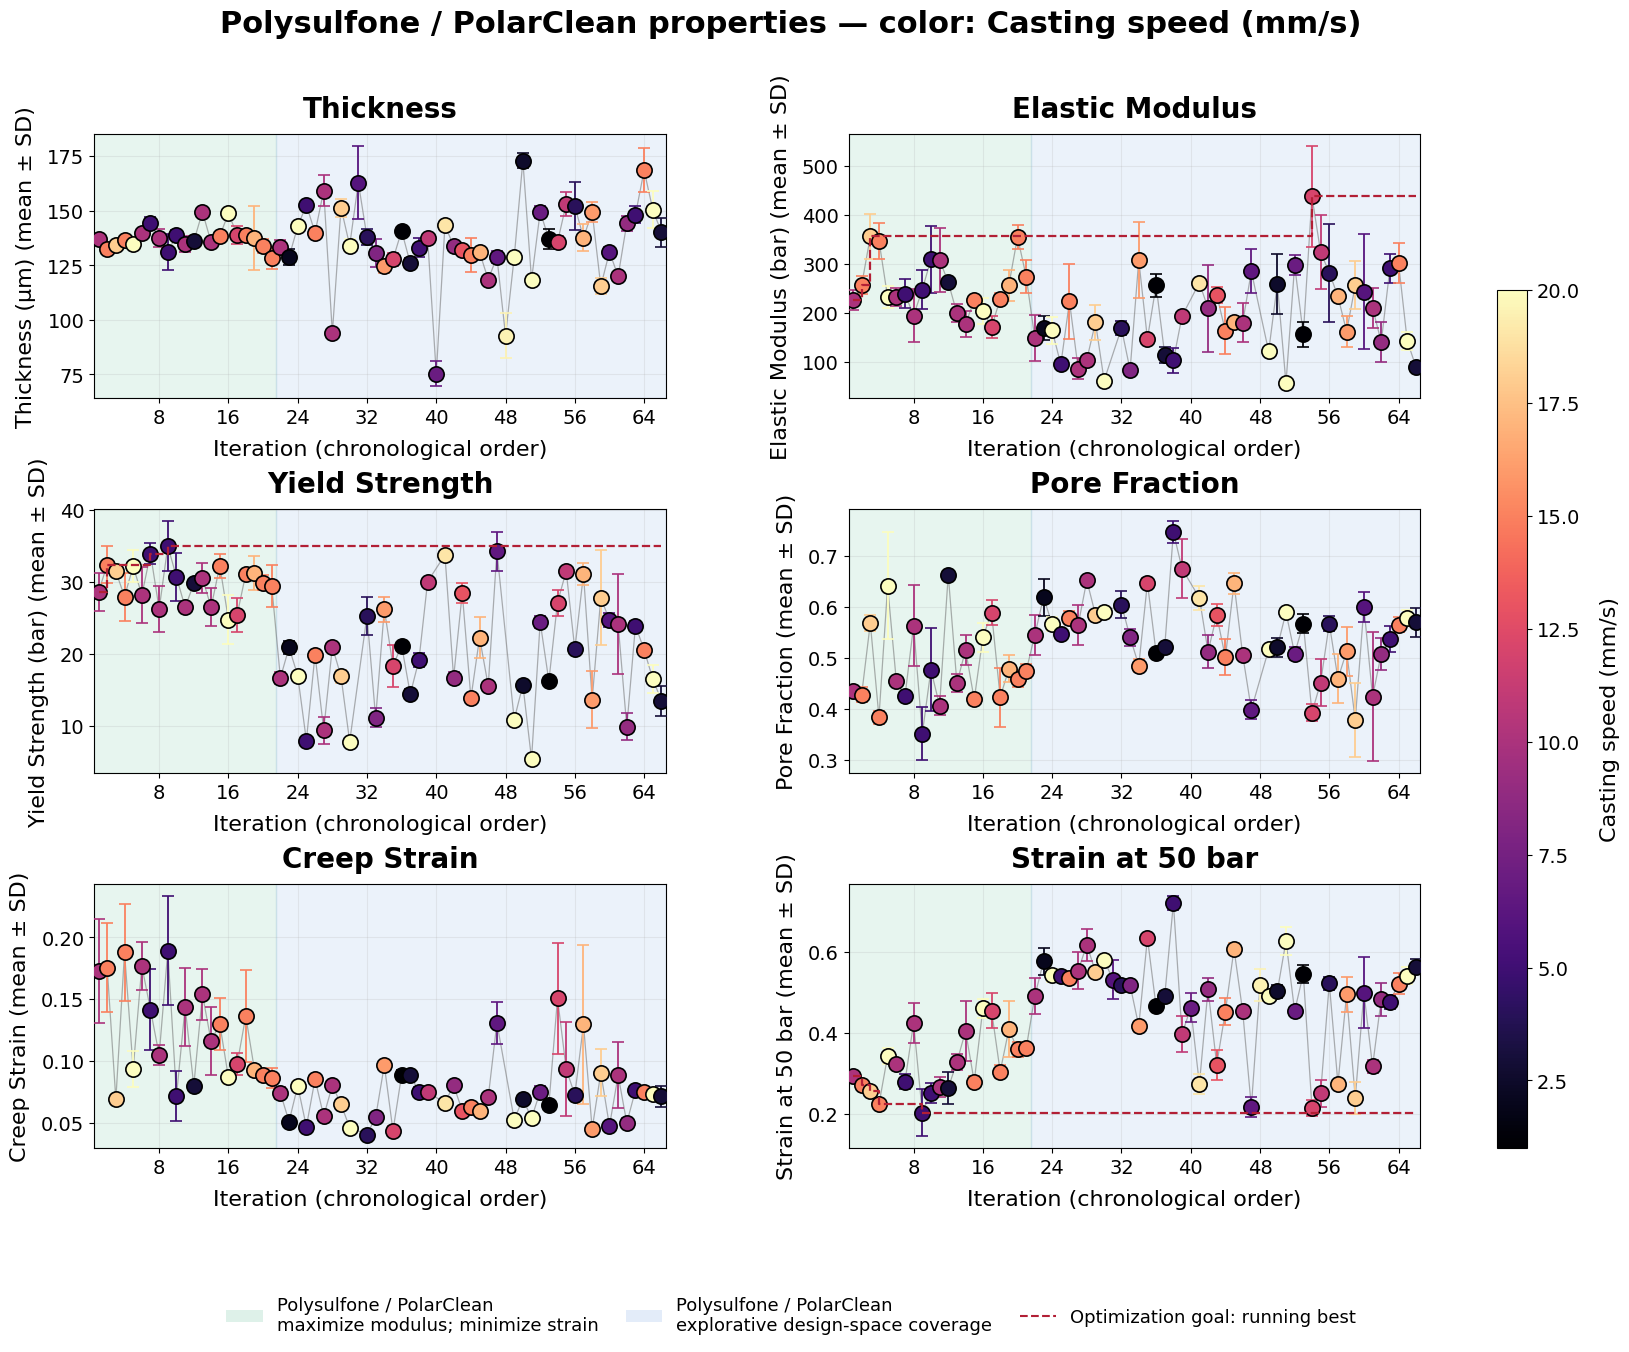

In [53]:
figure_polymer, axes_polymer, campaign_detailed = plot_detailed_campaign(
    campaign, PROPERTIES, 'polymer_wt', 'Polymer concentration (wt%)',
    connect_points=CONNECT_POINTS, cmap='viridis'
)
figure_humidity, axes_humidity, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'Humidity Mean', 'Ambient humidity (%)',
    nitrogen_markers=True, connect_points=CONNECT_POINTS, cmap='Blues'
)
figure_exposure, axes_exposure, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'coupon_to_bath_wait_time', 'Exposure time: coupon to bath (s)',
    connect_points=CONNECT_POINTS, cmap='cividis'
)
figure_bath, axes_bath, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'bath_temp', 'Bath temperature (°C)',
    connect_points=CONNECT_POINTS, cmap='plasma'
)
figure_casting, axes_casting, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'pullcast_speed', 'Casting speed (mm/s)',
    connect_points=CONNECT_POINTS, cmap='magma'
)
plt.show()

## Cross-validated feature importance

This section estimates which controllable and environmental variables are most useful for predicting each selected property. It uses a regularized linear (ridge) model with **repeated cross-validated permutation importance**. Importance is the increase in held-out mean absolute error (MAE) after shuffling one feature; larger positive values indicate greater predictive value.

Permutation importance measures **predictive usefulness, not effect direction**. Direction is therefore shown separately using the ridge coefficient for each standardized feature, averaged across the same cross-validation fits. A positive signed effect means higher feature values are associated with a higher predicted response; a negative effect means they are associated with a lower predicted response. Coefficients are normalized to the largest absolute effect within each response for visualization. These are conditional model associations—not causal effects—and correlated inputs can change or redistribute their signs.

Here, confidence means **stability across repeated train/test splits**, not a classical hypothesis-test confidence level. The table reports a 2.5th-to-97.5th percentile uncertainty interval across split repetitions, `probability_positive` (the fraction of repetitions with importance above zero), and `top_3_fraction` (how often the feature ranks among the three most important). A feature is `stable positive` only when its entire interval is above zero, `stable negative` when the interval is below zero, and `uncertain` otherwise.

The heatmap normalizes positive importances within each response so patterns can be compared across properties with different units. The detailed table retains raw mean importance and fold/repeat variability. With only about 31 samples, treat these rankings as exploratory associations—not causal effects. Correlated process settings may share or mask importance.

In [54]:
import numpy as np

FEATURES = {
    'polymer_wt': 'Polymer concentration (wt%)',
    'mixing_temp': 'Mixing temperature (°C)',
    'bath_temp': 'Bath temperature (°C)',
    'pullcast_speed': 'Casting speed (mm/s)',
    'nitrogen': 'Nitrogen on/off',
    'nitrogen_exposure_time': 'Exposure time - N2 on (s)',
    'air_exposure_time': 'Exposure time - N2 off (s)',
    'nips_bath_wait_time': 'Bath residence time (s)',
    'Humidity Mean': 'Ambient humidity (%)',
}
MIN_TARGET_SAMPLES = 12
N_CV_REPEATS = 50
N_PERMUTATION_REPEATS = 10
RANDOM_STATE = 42
RIDGE_ALPHA = 1.0
FEATURE_IMPORTANCE_PROPERTIES = list(PROPERTIES) + ['CV']

def nitrogen_to_binary(value):
    """Convert CSV boolean/string nitrogen values without relying on another cell."""
    return 1 if (value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}) else 0

def cross_validated_permutation_importance(data, properties, features=FEATURES):
    records = []
    for property_name in properties:
        target_column = f'{property_name} Mean'
        usable = data.dropna(subset=[target_column]).copy()
        if len(usable) < MIN_TARGET_SAMPLES:
            print(f'Skipping {property_name}: only {len(usable)} usable samples')
            continue
        X = usable[list(features)].copy()
        X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
        X = X.apply(pd.to_numeric, errors='coerce')
        # Drop constants: they cannot have permutation importance in this subset.
        variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
        X = X[variable_columns]
        y = pd.to_numeric(usable[target_column], errors='coerce')
        splits = min(5, max(3, len(usable) // 5))
        repeat_importances = []
        repeat_coefficients = []
        for cv_repeat in range(N_CV_REPEATS):
            split_generator = np.random.RandomState(RANDOM_STATE + cv_repeat)
            shuffled_indices = split_generator.permutation(len(X))
            validation_folds = np.array_split(shuffled_indices, splits)
            weighted_sum = np.zeros(X.shape[1])
            weighted_coefficient_sum = np.zeros(X.shape[1])
            held_out_count = 0
            for fold, test_index in enumerate(validation_folds, start=1):
                train_index = np.setdiff1d(shuffled_indices, test_index)
                X_train_frame, X_test_frame = X.iloc[train_index], X.iloc[test_index]
                medians = X_train_frame.median()
                X_train = X_train_frame.fillna(medians).to_numpy(dtype=float)
                X_test = X_test_frame.fillna(medians).to_numpy(dtype=float)
                center, scale = X_train.mean(axis=0), X_train.std(axis=0)
                scale[scale == 0] = 1
                X_train = (X_train - center) / scale
                X_test = (X_test - center) / scale
                y_train = y.iloc[train_index].to_numpy(dtype=float)
                y_test = y.iloc[test_index].to_numpy(dtype=float)
                y_center = y_train.mean()
                coefficients = np.linalg.solve(
                    X_train.T @ X_train + RIDGE_ALPHA * np.eye(X_train.shape[1]),
                    X_train.T @ (y_train - y_center),
                )
                baseline_error = np.mean(np.abs(y_test - (y_center + X_test @ coefficients)))
                fold_values = np.zeros((X.shape[1], N_PERMUTATION_REPEATS))
                fold_generator = np.random.RandomState(RANDOM_STATE + 1000 * cv_repeat + fold)
                for feature_index in range(X.shape[1]):
                    for permutation_repeat in range(N_PERMUTATION_REPEATS):
                        permuted = X_test.copy()
                        permuted[:, feature_index] = fold_generator.permutation(permuted[:, feature_index])
                        permuted_error = np.mean(np.abs(
                            y_test - (y_center + permuted @ coefficients)
                        ))
                        fold_values[feature_index, permutation_repeat] = permuted_error - baseline_error
                weighted_sum += fold_values.mean(axis=1) * len(test_index)
                weighted_coefficient_sum += coefficients * len(test_index)
                held_out_count += len(test_index)
            repeat_importances.append(weighted_sum / held_out_count)
            repeat_coefficients.append(weighted_coefficient_sum / held_out_count)
        repeat_importances = np.asarray(repeat_importances)
        repeat_coefficients = np.asarray(repeat_coefficients)
        repeat_ranks = np.argsort(np.argsort(-repeat_importances, axis=1), axis=1) + 1
        for feature_index, feature in enumerate(variable_columns):
            values = repeat_importances[:, feature_index]
            coefficient_values = repeat_coefficients[:, feature_index]
            interval_low, interval_high = np.percentile(values, [2.5, 97.5])
            probability_positive = np.mean(values > 0)
            stability_label = ('stable positive' if interval_low > 0 else
                               'stable negative' if interval_high < 0 else 'uncertain')
            records.append({
                'property': property_name, 'feature': features[feature],
                'importance_mean': values.mean(),
                'importance_interval_low': interval_low,
                'importance_interval_high': interval_high,
                'probability_positive': probability_positive,
                'top_3_fraction': np.mean(repeat_ranks[:, feature_index] <= min(3, X.shape[1])),
                'stability': stability_label,
                'signed_effect_mean': coefficient_values.mean(),
                'signed_effect_interval_low': np.percentile(coefficient_values, 2.5),
                'signed_effect_interval_high': np.percentile(coefficient_values, 97.5),
                'probability_effect_positive': np.mean(coefficient_values > 0),
                'importance_sd_across_splits': values.std(ddof=1),
                'n_samples': len(usable), 'n_folds': splits, 'n_cv_repeats': N_CV_REPEATS,
            })
    return pd.DataFrame(records).sort_values(['property', 'importance_mean'], ascending=[True, False])

feature_importance = cross_validated_permutation_importance(
    campaign_detailed, FEATURE_IMPORTANCE_PROPERTIES
)
feature_importance.head(20)

,property,feature,importance_mean,importance_interval_low,importance_interval_high,probability_positive,top_3_fraction,stability,signed_effect_mean,signed_effect_interval_low,signed_effect_interval_high,probability_effect_positive,importance_sd_across_splits,n_samples,n_folds,n_cv_repeats
54,CV,Polymer concentration (wt%),0.001931,0.000690,0.002812,0.98,0.98,stable positive,0.010184,0.009738,0.010709,1.00,0.000626,61,5,50
62,CV,Ambient humidity (%),0.001452,0.000433,0.002696,1.00,0.96,stable positive,-0.009497,-0.009973,-0.008990,0.00,0.000644,61,5,50
57,CV,Casting speed (mm/s),0.000469,-0.000619,0.001136,0.78,0.50,uncertain,-0.005348,-0.005916,-0.004890,0.00,0.000526,61,5,50
59,CV,Exposure time - N2 on (s),0.000381,-0.000328,0.001065,0.82,0.30,uncertain,0.006664,0.006162,0.007275,1.00,0.000422,61,5,50
56,CV,Bath temperature (°C),0.000204,-0.001053,0.001087,0.76,0.20,uncertain,-0.004827,-0.005384,-0.004398,0.00,0.000514,61,5,50
60,CV,Exposure time - N2 off (s),-0.000068,-0.000709,0.000461,0.36,0.02,uncertain,-0.002285,-0.002808,-0.001773,0.00,0.000338,61,5,50
58,CV,Nitrogen on/off,-0.000071,-0.001066,0.000754,0.52,0.02,uncertain,0.003688,0.003020,0.004286,1.00,0.000526,61,5,50
61,CV,Bath residence time (s),-0.000269,-0.000961,0.000171,0.24,0.02,uncertain,0.001137,0.000620,0.001616,1.00,0.000353,61,5,50
55,CV,Mixing temperature (°C),-0.000304,-0.001074,0.000298,0.12,0.00,uncertain,0.001188,0.000667,0.001736,1.00,0.000356,61,5,50
36,Creep Strain,Polymer concentration (wt%),0.008098,0.006557,0.009384,1.00,1.00,stable positive,0.019300,0.018934,0.019609,1.00,0.000881,63,5,50


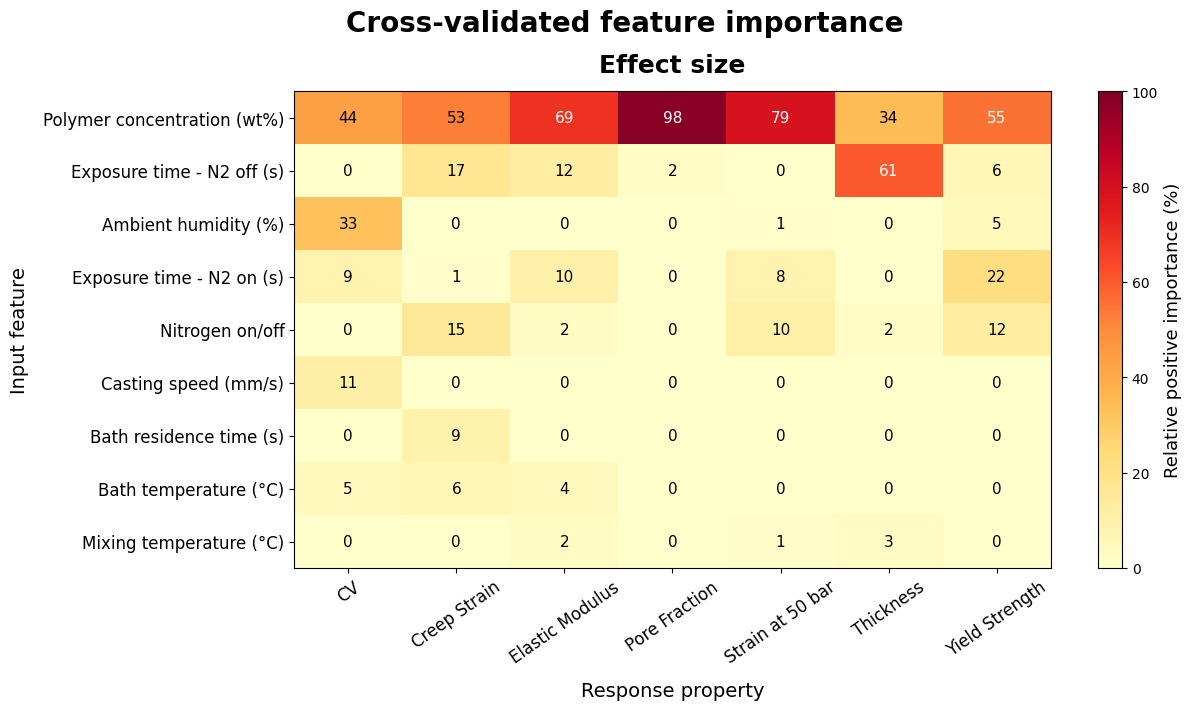

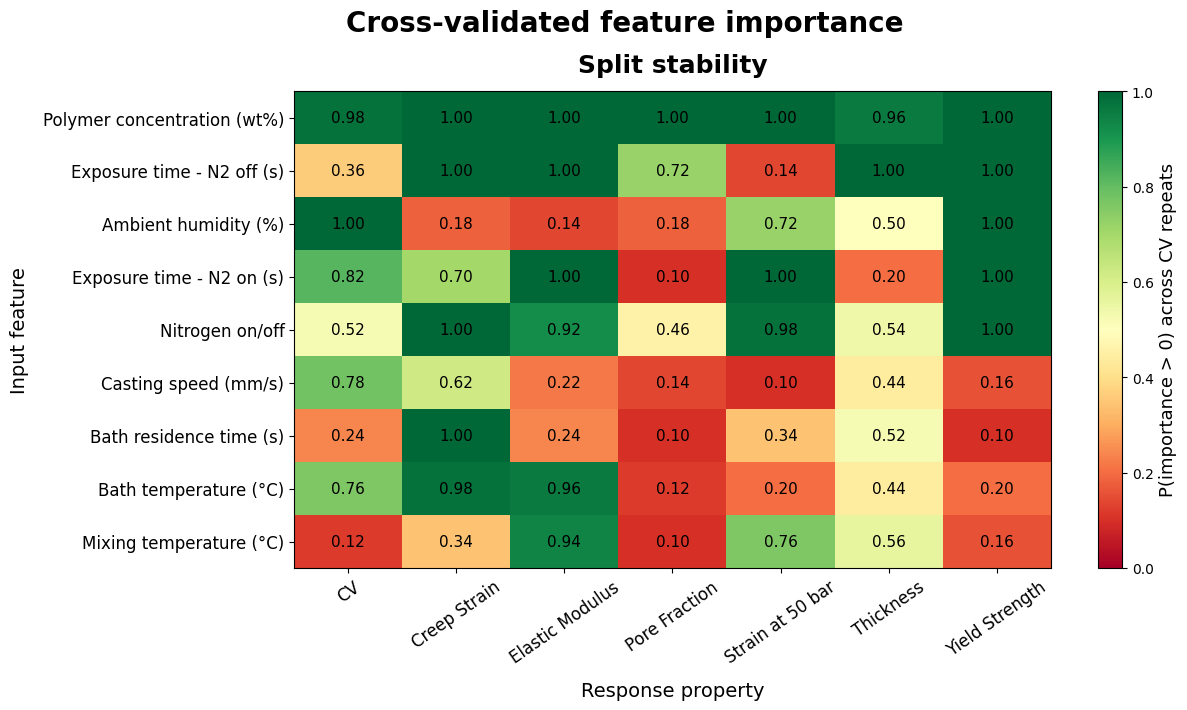

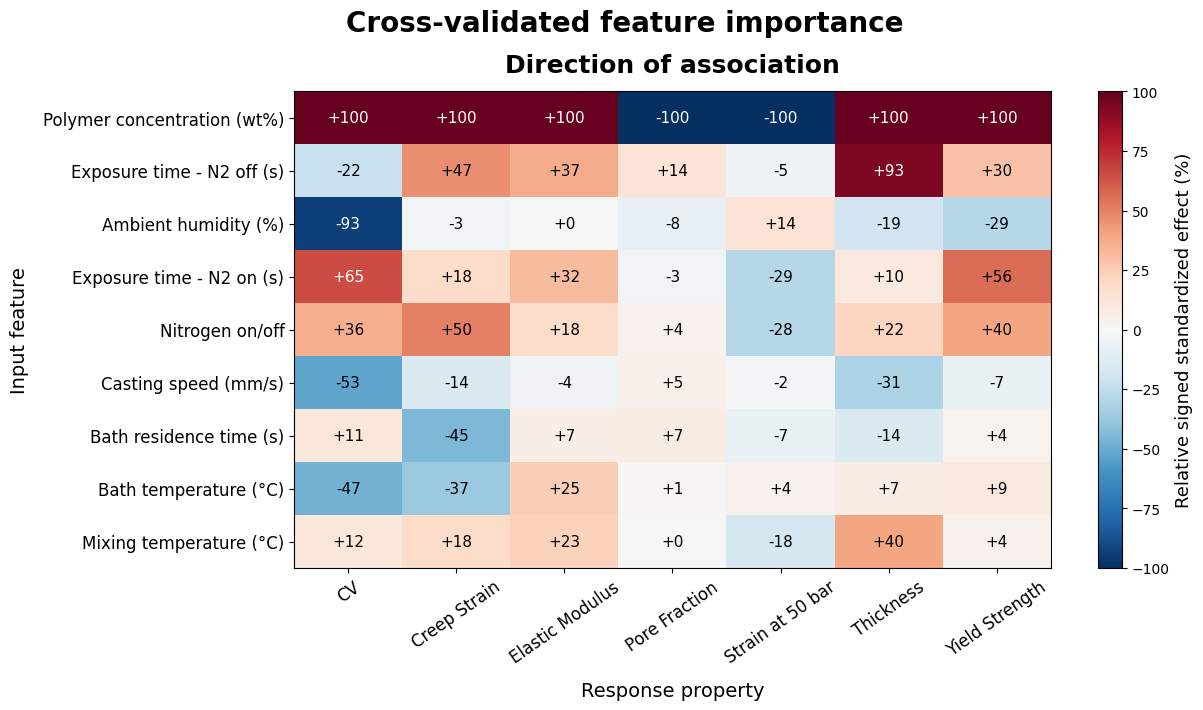

In [55]:
# Normalize positive importance within each property for a comparable 0–100% heatmap.
importance_for_plot = feature_importance.copy()
importance_for_plot['positive_importance'] = importance_for_plot['importance_mean'].clip(lower=0)
importance_for_plot['relative_importance'] = importance_for_plot.groupby('property')['positive_importance'].transform(
    lambda values: 100 * values / values.sum() if values.sum() > 0 else values
)
importance_matrix = importance_for_plot.pivot(index='feature', columns='property', values='relative_importance').fillna(0)
feature_order = importance_matrix.max(axis=1).sort_values(ascending=False).index
importance_matrix = importance_matrix.loc[feature_order]
confidence_matrix = importance_for_plot.pivot(index='feature', columns='property', values='probability_positive').fillna(0.5)
confidence_matrix = confidence_matrix.reindex(index=feature_order, columns=importance_matrix.columns)
importance_for_plot['relative_signed_effect'] = importance_for_plot.groupby('property')['signed_effect_mean'].transform(
    lambda values: 100 * values / values.abs().max() if values.abs().max() > 0 else values
)
signed_effect_matrix = importance_for_plot.pivot(index='feature', columns='property', values='relative_signed_effect').fillna(0)
signed_effect_matrix = signed_effect_matrix.reindex(index=feature_order, columns=importance_matrix.columns)

importance_figsize = (max(12, 1.8 * len(importance_matrix.columns)), max(7, 0.8 * len(importance_matrix.index)))
figure_importance, importance_axis = plt.subplots(figsize=importance_figsize)
figure_importance_confidence, confidence_axis = plt.subplots(figsize=importance_figsize)
figure_importance_direction, signed_effect_axis = plt.subplots(figsize=importance_figsize)
heatmap = importance_axis.imshow(importance_matrix.to_numpy(), cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
confidence_heatmap = confidence_axis.imshow(confidence_matrix.to_numpy(), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
signed_effect_heatmap = signed_effect_axis.imshow(signed_effect_matrix.to_numpy(), cmap='RdBu_r', vmin=-100, vmax=100, aspect='auto')
for axis, matrix in [(importance_axis, importance_matrix), (confidence_axis, confidence_matrix),
                     (signed_effect_axis, signed_effect_matrix)]:
    axis.set_xticks(range(len(matrix.columns)))
    axis.set_xticklabels(matrix.columns)
    axis.set_yticks(range(len(matrix.index)))
    axis.set_yticklabels(matrix.index)
    axis.tick_params(axis='x', labelsize=12, rotation=35)
    axis.tick_params(axis='y', labelsize=12)
for row_index in range(len(importance_matrix.index)):
    for column_index in range(len(importance_matrix.columns)):
        effect = importance_matrix.iloc[row_index, column_index]
        confidence = confidence_matrix.iloc[row_index, column_index]
        signed_effect = signed_effect_matrix.iloc[row_index, column_index]
        importance_axis.text(column_index, row_index, f'{effect:.0f}', ha='center', va='center',
                             fontsize=11, color='white' if effect > 55 else 'black')
        confidence_axis.text(column_index, row_index, f'{confidence:.2f}', ha='center', va='center', fontsize=11)
        signed_effect_axis.text(column_index, row_index, f'{signed_effect:+.0f}', ha='center', va='center',
                                fontsize=11, color='white' if abs(signed_effect) > 60 else 'black')
importance_colorbar = figure_importance.colorbar(heatmap, ax=importance_axis)
importance_colorbar.set_label('Relative positive importance (%)', fontsize=13)
confidence_colorbar = figure_importance_confidence.colorbar(confidence_heatmap, ax=confidence_axis)
confidence_colorbar.set_label('P(importance > 0) across CV repeats', fontsize=13)
signed_effect_colorbar = figure_importance_direction.colorbar(signed_effect_heatmap, ax=signed_effect_axis)
signed_effect_colorbar.set_label('Relative signed standardized effect (%)', fontsize=13)
importance_axis.set_title('Effect size', fontsize=18, fontweight='semibold', pad=14)
confidence_axis.set_title('Split stability', fontsize=18, fontweight='semibold', pad=14)
signed_effect_axis.set_title('Direction of association', fontsize=18, fontweight='semibold', pad=14)
importance_axis.set_xlabel('Response property', fontsize=14, labelpad=10)
confidence_axis.set_xlabel('Response property', fontsize=14, labelpad=10)
signed_effect_axis.set_xlabel('Response property', fontsize=14, labelpad=10)
importance_axis.set_ylabel('Input feature', fontsize=14, labelpad=10)
confidence_axis.set_ylabel('Input feature', fontsize=14, labelpad=10)
signed_effect_axis.set_ylabel('Input feature', fontsize=14, labelpad=10)
for figure in (figure_importance, figure_importance_confidence, figure_importance_direction):
    figure.suptitle('Cross-validated feature importance', fontsize=20, fontweight='semibold')
    figure.tight_layout()
plt.show()

## Coupled nitrogen–exposure response surfaces

These panels use the same ridge specification to predict each property while varying nitrogen state and coupon-to-bath exposure time together. All other features are held at their median values. Black-edged points are the actual experiments. Because nitrogen is binary, only the **off** and **on** rows are physically observed; shading between them is visual interpolation, not an intermediate nitrogen setting.

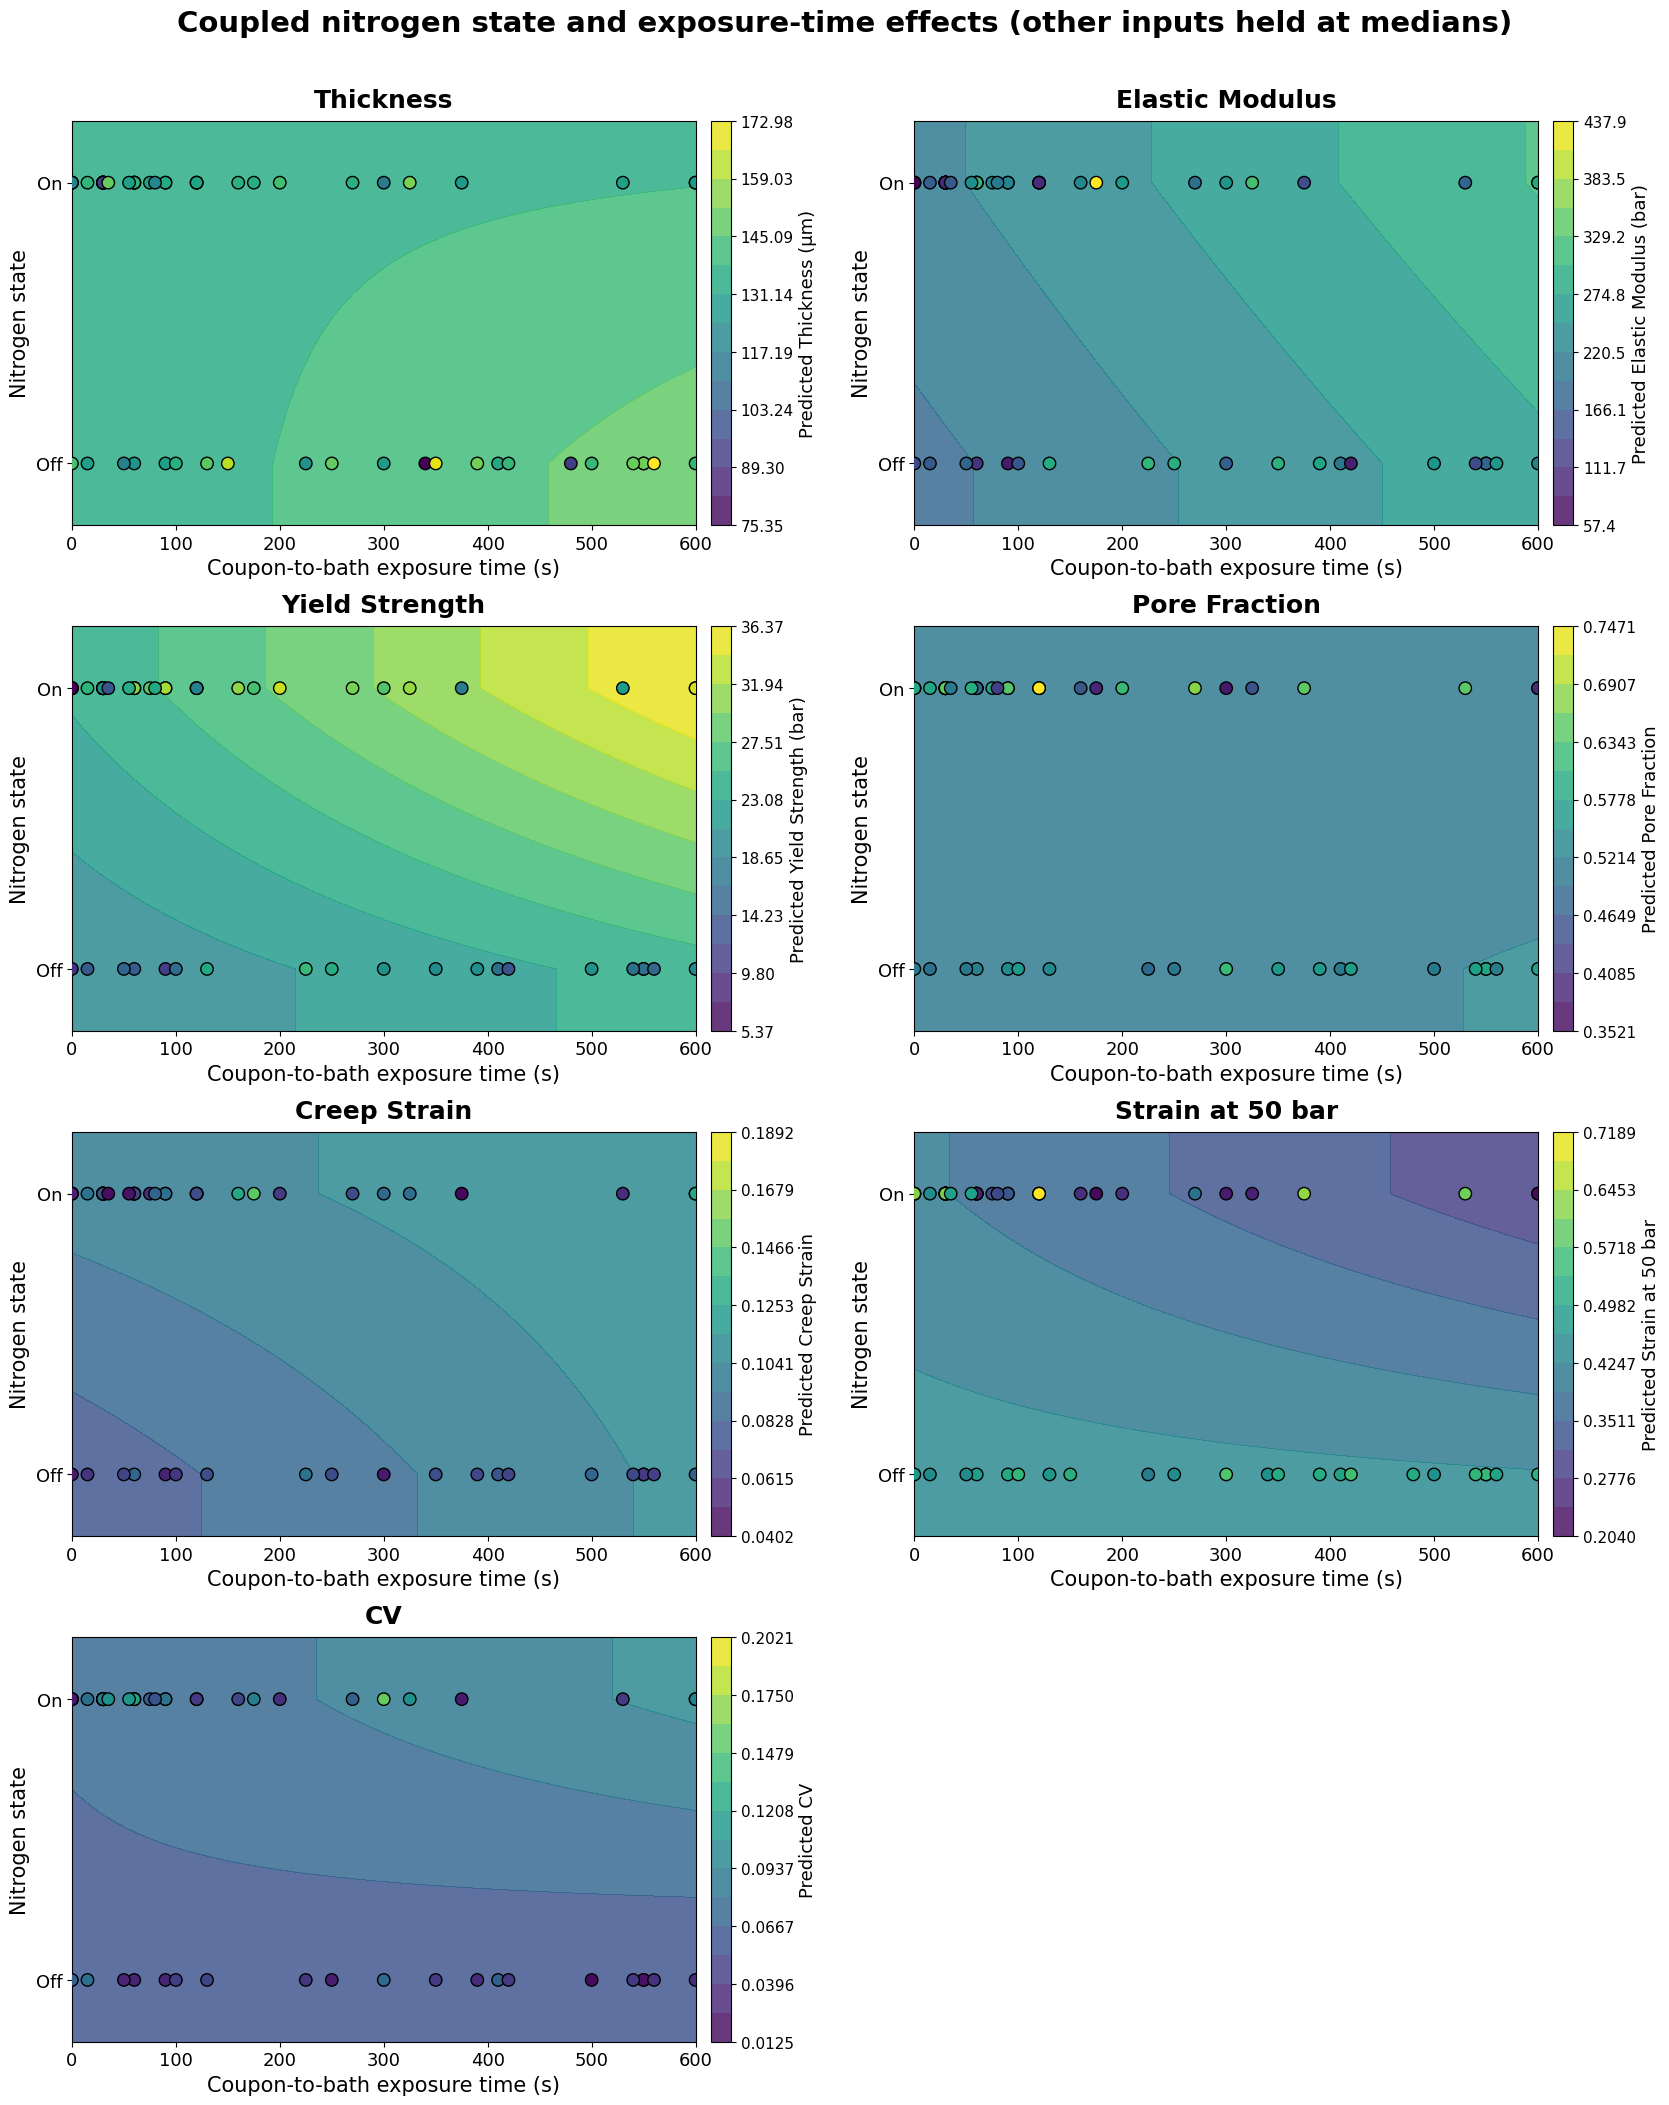

In [56]:
def fit_ridge_response_surface(data, property_name, features=FEATURES):
    target_column = f'{property_name} Mean'
    usable = data.dropna(subset=[target_column]).copy()
    X = usable[list(features)].copy()
    X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
    X = X.apply(pd.to_numeric, errors='coerce')
    variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
    X = X[variable_columns]
    medians = X.median()
    X_numeric = X.fillna(medians).to_numpy(dtype=float)
    center, scale = X_numeric.mean(axis=0), X_numeric.std(axis=0)
    scale[scale == 0] = 1
    X_standardized = (X_numeric - center) / scale
    y = pd.to_numeric(usable[target_column], errors='coerce').to_numpy(dtype=float)
    baseline = y.mean()
    coefficients = np.linalg.solve(
        X_standardized.T @ X_standardized + RIDGE_ALPHA * np.eye(X_standardized.shape[1]),
        X_standardized.T @ (y - baseline),
    )
    exposure_grid = np.linspace(0, data['coupon_to_bath_wait_time'].max(), 121)
    surface_rows = []
    for nitrogen_state in (0, 1):
        grid = pd.DataFrame([medians.to_dict()] * len(exposure_grid))[variable_columns]
        if 'nitrogen' in grid:
            grid['nitrogen'] = nitrogen_state
        if 'nitrogen_exposure_time' in grid:
            grid['nitrogen_exposure_time'] = exposure_grid * nitrogen_state
        if 'air_exposure_time' in grid:
            grid['air_exposure_time'] = exposure_grid * (1 - nitrogen_state)
        grid_standardized = (grid.to_numpy(dtype=float) - center) / scale
        surface_rows.append(baseline + grid_standardized @ coefficients)
    return exposure_grid, np.vstack(surface_rows), usable

surface_properties = [prop for prop in FEATURE_IMPORTANCE_PROPERTIES
                      if campaign_detailed[f'{prop} Mean'].notna().sum() >= MIN_TARGET_SAMPLES]
surface_columns = 2
surface_rows = int(np.ceil(len(surface_properties) / surface_columns))
figure_nitrogen_exposure, surface_grid = plt.subplots(
    surface_rows, surface_columns, figsize=(17, 5.2 * surface_rows), squeeze=False
)
axes_nitrogen_exposure = list(surface_grid.flat)
for axis, property_name in zip(axes_nitrogen_exposure, surface_properties):
    exposure_grid, predicted_surface, observed = fit_ridge_response_surface(campaign_detailed, property_name)
    target_column = f'{property_name} Mean'
    value_min = min(predicted_surface.min(), observed[target_column].min())
    value_max = max(predicted_surface.max(), observed[target_column].max())
    levels = np.linspace(value_min, value_max, 15)
    # Duplicate the binary-state predictions into padded margins so observations
    # at 0 and 1 sit inside the colored field rather than on its outer edges.
    padded_states = [-0.22, 0, 1, 1.22]
    padded_surface = np.vstack([predicted_surface[0], predicted_surface[0],
                                predicted_surface[1], predicted_surface[1]])
    contour = axis.contourf(exposure_grid, padded_states, padded_surface, levels=levels, cmap='viridis', alpha=0.82)
    axis.scatter(observed['coupon_to_bath_wait_time'], observed['nitrogen_binary'],
                 c=observed[target_column], cmap='viridis', vmin=value_min, vmax=value_max,
                 s=80, edgecolor='black', linewidth=1.0, zorder=3)
    axis.set_title(property_name, fontsize=18, fontweight='semibold', pad=10)
    axis.set_xlabel('Coupon-to-bath exposure time (s)', fontsize=15)
    axis.set_ylabel('Nitrogen state', fontsize=15)
    axis.set_yticks([0, 1])
    axis.set_yticklabels(['Off', 'On'], fontsize=13)
    axis.set_ylim(-0.22, 1.22)
    axis.tick_params(axis='x', labelsize=13)
    property_colorbar = figure_nitrogen_exposure.colorbar(contour, ax=axis, pad=0.02)
    property_colorbar.set_label(f'Predicted {property_label(property_name)}', fontsize=13)
    property_colorbar.ax.tick_params(labelsize=11)
for axis in axes_nitrogen_exposure[len(surface_properties):]:
    axis.remove()
figure_nitrogen_exposure.suptitle(
    'Coupled nitrogen state and exposure-time effects (other inputs held at medians)',
    fontsize=21, fontweight='semibold', y=1.01
)
figure_nitrogen_exposure.tight_layout()
plt.show()

## Ambient-humidity–exposure response surfaces

These panels vary ambient SHT40 humidity and coupon-to-bath exposure time while holding the remaining inputs at their medians. Predictions are averaged equally across a nitrogen-off prediction and a nitrogen-on prediction, so the surface represents a balanced nitrogen-marginalized response rather than assuming one nitrogen state. Actual experiments are overlaid as circles (N2 on) and squares (N2 off).

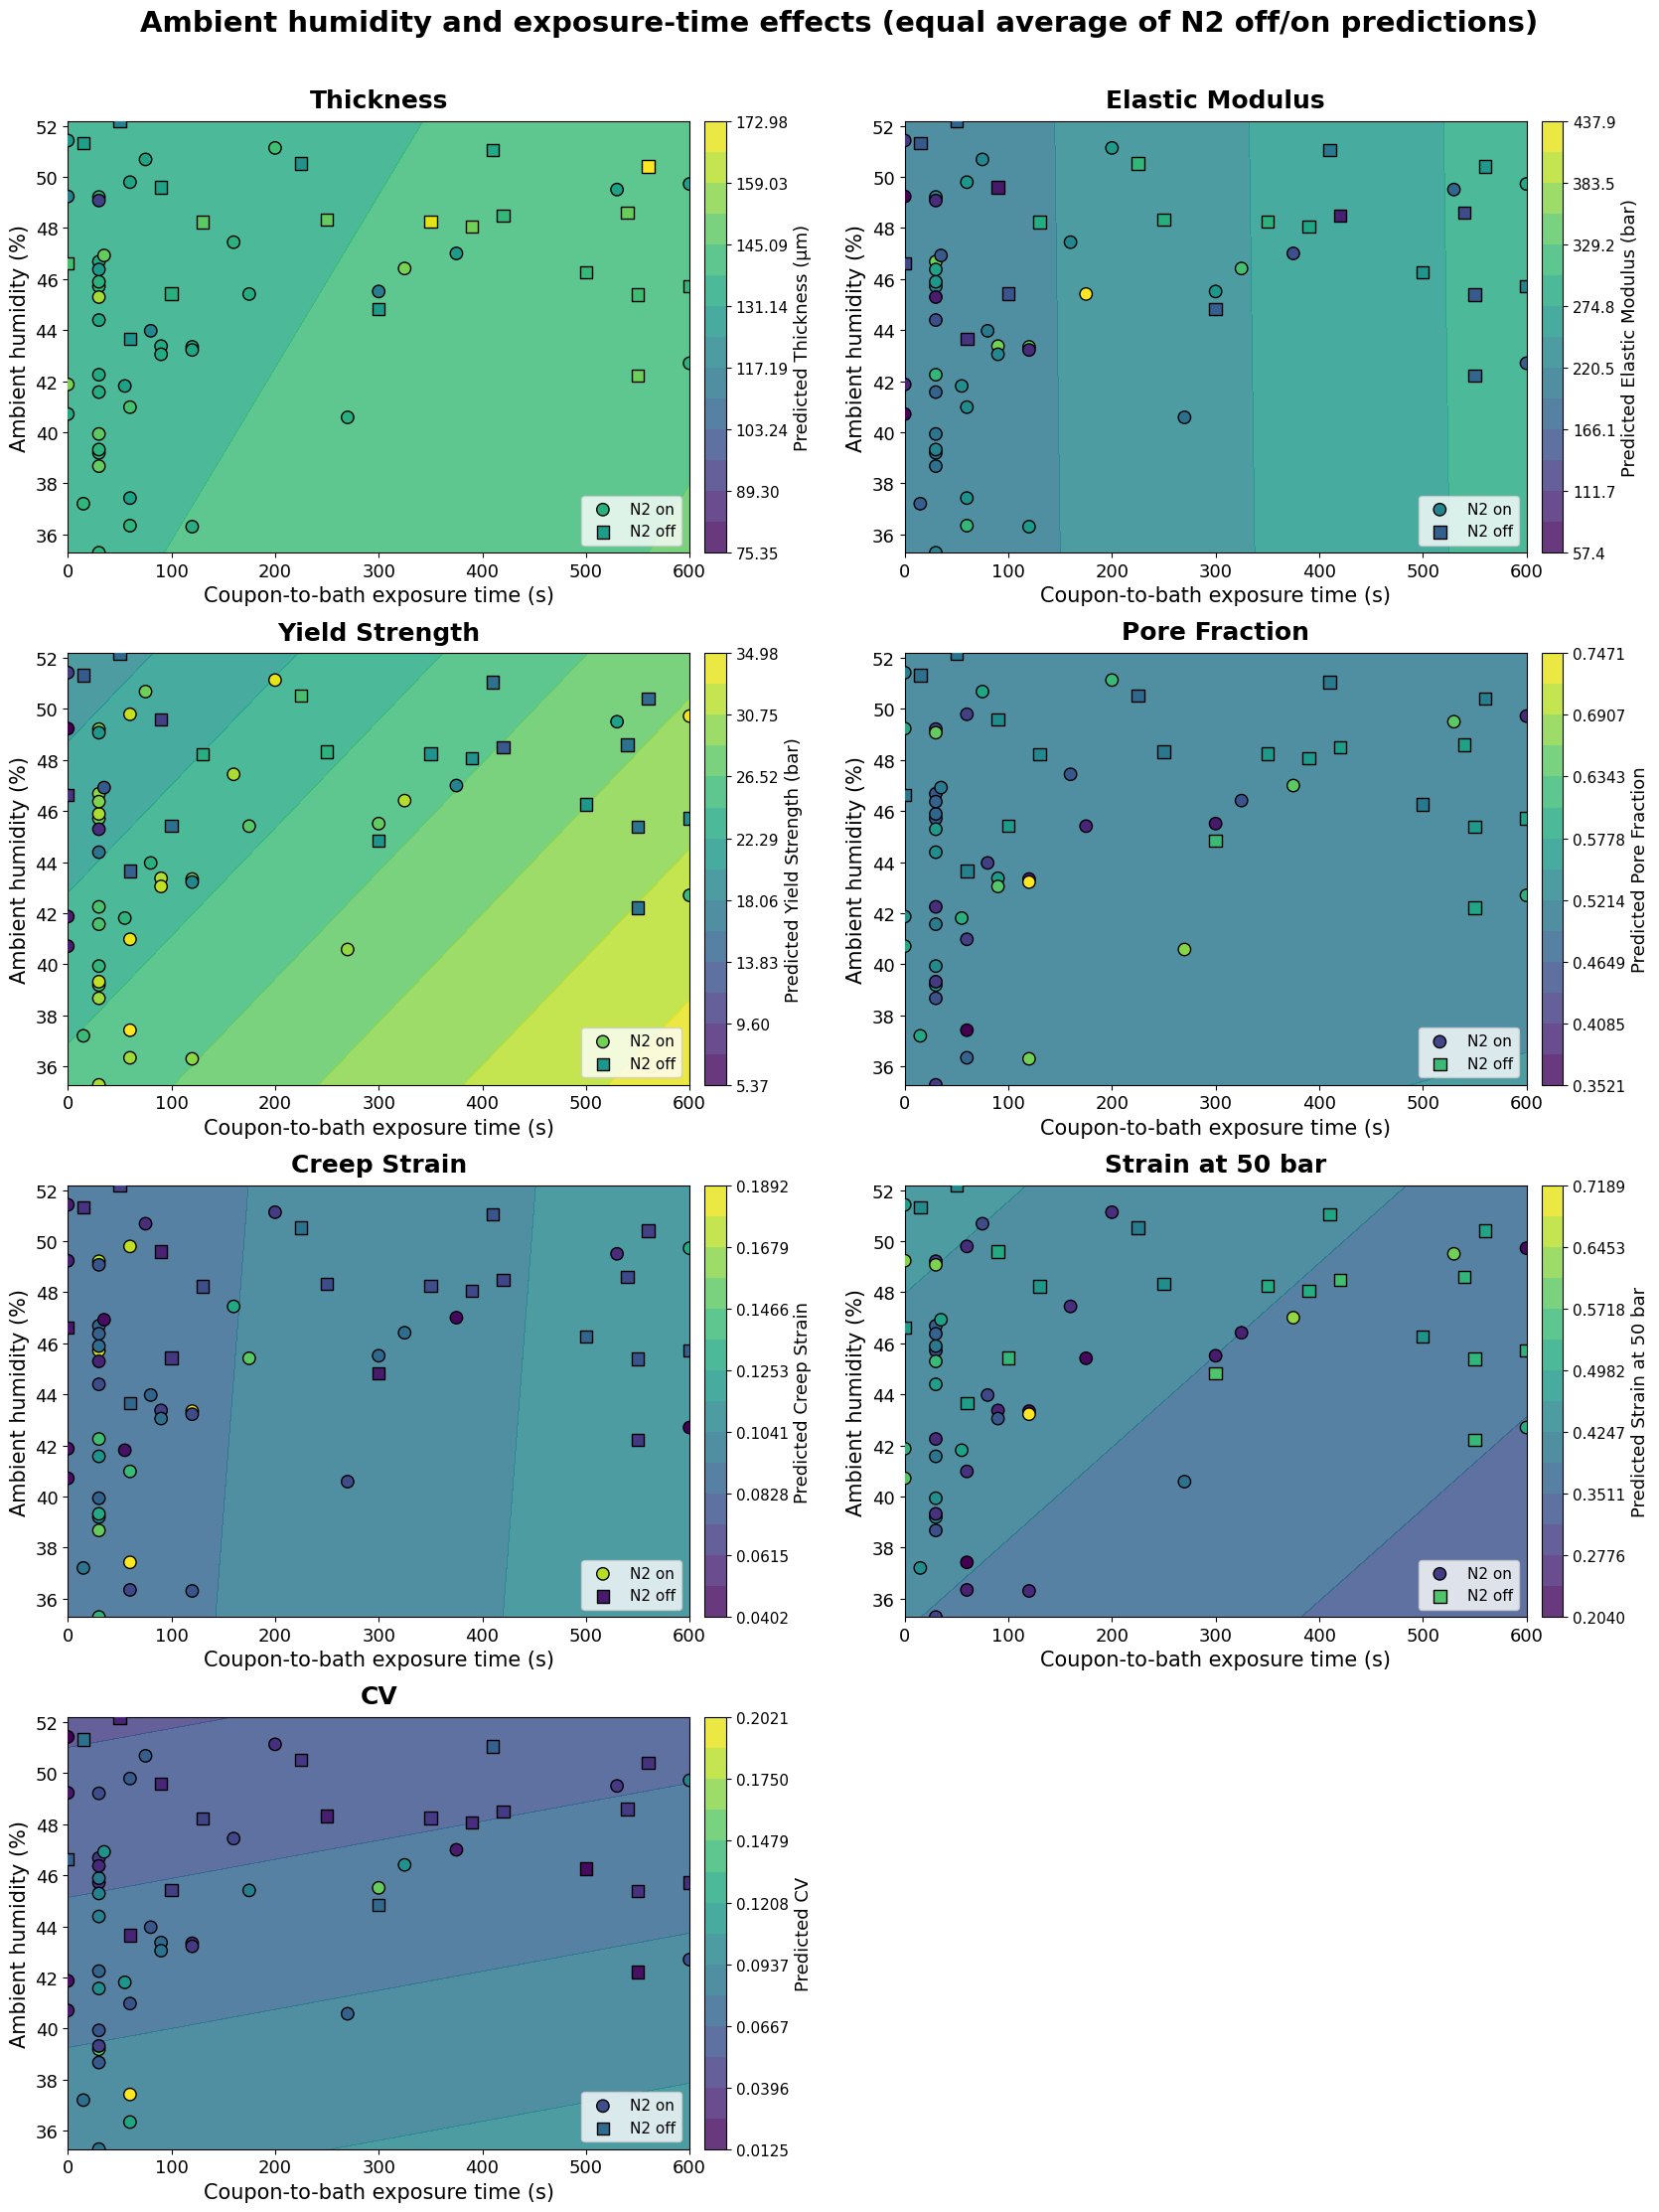

In [57]:
def fit_humidity_exposure_surface(data, property_name, features=FEATURES):
    target_column = f'{property_name} Mean'
    usable = data.dropna(subset=[target_column]).copy()
    X = usable[list(features)].copy()
    X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
    X = X.apply(pd.to_numeric, errors='coerce')
    variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
    X = X[variable_columns]
    medians = X.median()
    X_numeric = X.fillna(medians).to_numpy(dtype=float)
    center, scale = X_numeric.mean(axis=0), X_numeric.std(axis=0)
    scale[scale == 0] = 1
    X_standardized = (X_numeric - center) / scale
    y = pd.to_numeric(usable[target_column], errors='coerce').to_numpy(dtype=float)
    baseline = y.mean()
    coefficients = np.linalg.solve(
        X_standardized.T @ X_standardized + RIDGE_ALPHA * np.eye(X_standardized.shape[1]),
        X_standardized.T @ (y - baseline),
    )
    humidity_observed = pd.to_numeric(data['Humidity Mean'], errors='coerce').dropna()
    humidity_grid = np.linspace(humidity_observed.min(), humidity_observed.max(), 80)
    exposure_grid = np.linspace(0, data['coupon_to_bath_wait_time'].max(), 100)
    exposure_mesh, humidity_mesh = np.meshgrid(exposure_grid, humidity_grid)
    state_predictions = []
    for nitrogen_state in (0, 1):
        grid = pd.DataFrame([medians.to_dict()] * exposure_mesh.size)[variable_columns]
        if 'Humidity Mean' in grid:
            grid['Humidity Mean'] = humidity_mesh.ravel()
        if 'nitrogen' in grid:
            grid['nitrogen'] = nitrogen_state
        if 'nitrogen_exposure_time' in grid:
            grid['nitrogen_exposure_time'] = exposure_mesh.ravel() * nitrogen_state
        if 'air_exposure_time' in grid:
            grid['air_exposure_time'] = exposure_mesh.ravel() * (1 - nitrogen_state)
        grid_standardized = (grid.to_numpy(dtype=float) - center) / scale
        state_predictions.append((baseline + grid_standardized @ coefficients).reshape(humidity_mesh.shape))
    marginalized_surface = np.mean(state_predictions, axis=0)
    return exposure_mesh, humidity_mesh, marginalized_surface, usable

figure_humidity_exposure, humidity_surface_grid = plt.subplots(
    surface_rows, surface_columns, figsize=(17, 5.5 * surface_rows), squeeze=False
)
axes_humidity_exposure = list(humidity_surface_grid.flat)
for axis, property_name in zip(axes_humidity_exposure, surface_properties):
    exposure_mesh, humidity_mesh, predicted_surface, observed = fit_humidity_exposure_surface(
        campaign_detailed, property_name
    )
    target_column = f'{property_name} Mean'
    value_min = min(predicted_surface.min(), observed[target_column].min())
    value_max = max(predicted_surface.max(), observed[target_column].max())
    levels = np.linspace(value_min, value_max, 15)
    contour = axis.contourf(exposure_mesh, humidity_mesh, predicted_surface,
                            levels=levels, cmap='viridis', alpha=0.82)
    for nitrogen_state, marker, label in [(1, 'o', 'N2 on'), (0, 's', 'N2 off')]:
        state_points = observed[observed['nitrogen_binary'] == nitrogen_state]
        axis.scatter(state_points['coupon_to_bath_wait_time'], state_points['Humidity Mean'],
                     c=state_points[target_column], cmap='viridis', vmin=value_min, vmax=value_max,
                     marker=marker, s=80, edgecolor='black', linewidth=1.0, label=label, zorder=3)
    axis.set_title(property_name, fontsize=18, fontweight='semibold', pad=10)
    axis.set_xlabel('Coupon-to-bath exposure time (s)', fontsize=15)
    axis.set_ylabel('Ambient humidity (%)', fontsize=15)
    axis.tick_params(labelsize=13)
    axis.legend(fontsize=11, loc='best', frameon=True)
    property_colorbar = figure_humidity_exposure.colorbar(contour, ax=axis, pad=0.02)
    property_colorbar.set_label(f'Predicted {property_label(property_name)}', fontsize=13)
    property_colorbar.ax.tick_params(labelsize=11)
for axis in axes_humidity_exposure[len(surface_properties):]:
    axis.remove()
figure_humidity_exposure.suptitle(
    'Ambient humidity and exposure-time effects (equal average of N2 off/on predictions)',
    fontsize=21, fontweight='semibold', y=1.01
)
figure_humidity_exposure.tight_layout()
plt.show()

## Cross-validated pairwise interactions

Each hierarchical ridge model keeps every main effect and adds one standardized pairwise product. Positive MAE improvement means the interaction improves held-out prediction. The signed coefficient indicates whether a joint high–high setting predicts more (+) or less (−) than the additive effects imply. Stability is the fraction of 50 repeated CV splits improved by the interaction. These are exploratory conditional associations, not causal effects.

In [58]:
INTERACTION_FEATURES = {
    'polymer_wt': 'Polymer concentration (wt%)', 'mixing_temp': 'Mixing temperature (°C)',
    'bath_temp': 'Bath temperature (°C)', 'pullcast_speed': 'Casting speed (mm/s)',
    'nitrogen': 'Nitrogen on/off', 'coupon_to_bath_wait_time': 'Exposure time (s)',
    'nips_bath_wait_time': 'Bath residence time (s)', 'Humidity Mean': 'Ambient humidity (%)'}
INTERACTION_PAIRS = [('nitrogen', 'coupon_to_bath_wait_time'),
                     ('Humidity Mean', 'coupon_to_bath_wait_time'),
                     ('polymer_wt', 'mixing_temp'), ('polymer_wt', 'bath_temp'),
                     ('bath_temp', 'nips_bath_wait_time')]

def ridge_fit_predict(train, test, response):
    center = response.mean()
    coef = np.linalg.solve(train.T @ train + RIDGE_ALPHA * np.eye(train.shape[1]),
                           train.T @ (response - center))
    return center + test @ coef, coef

def repeated_interaction_analysis(data, properties):
    records = []
    for prop in properties:
        usable = data.dropna(subset=[f'{prop} Mean']).copy()
        if len(usable) < MIN_TARGET_SAMPLES: continue
        frame = usable[list(INTERACTION_FEATURES)].copy()
        frame['nitrogen'] = frame['nitrogen'].map(nitrogen_to_binary)
        frame = frame.apply(pd.to_numeric, errors='coerce')
        columns = [c for c in frame if frame[c].nunique(dropna=True) > 1]
        frame, response = frame[columns], pd.to_numeric(usable[f'{prop} Mean']).to_numpy(float)
        folds = min(5, max(3, len(frame) // 5))
        for first, second in INTERACTION_PAIRS:
            if first not in columns or second not in columns: continue
            gains, effects = [], []
            a, b = columns.index(first), columns.index(second)
            for repeat in range(N_CV_REPEATS):
                order = np.random.RandomState(RANDOM_STATE + repeat).permutation(len(frame))
                gain_sum = effect_sum = count = 0
                for test_index in np.array_split(order, folds):
                    train_index = np.setdiff1d(order, test_index)
                    train_frame, test_frame = frame.iloc[train_index], frame.iloc[test_index]
                    medians = train_frame.median()
                    train, test = train_frame.fillna(medians).to_numpy(float), test_frame.fillna(medians).to_numpy(float)
                    center, scale = train.mean(0), train.std(0); scale[scale == 0] = 1
                    train, test = (train-center)/scale, (test-center)/scale
                    train_product, test_product = train[:, a]*train[:, b], test[:, a]*test[:, b]
                    product_center, product_scale = train_product.mean(), train_product.std() or 1
                    train_product, test_product = (train_product-product_center)/product_scale, (test_product-product_center)/product_scale
                    y_train, y_test = response[train_index], response[test_index]
                    additive, _ = ridge_fit_predict(train, test, y_train)
                    coupled, coef = ridge_fit_predict(np.c_[train, train_product], np.c_[test, test_product], y_train)
                    n = len(test_index); count += n
                    gain_sum += (np.mean(abs(y_test-additive)) - np.mean(abs(y_test-coupled))) * n
                    effect_sum += coef[-1] * n
                gains.append(gain_sum/count); effects.append(effect_sum/count)
            gains, effects = np.asarray(gains), np.asarray(effects)
            low, high = np.percentile(gains, [2.5, 97.5])
            records.append({'property': prop, 'interaction': f'{INTERACTION_FEATURES[first]} × {INTERACTION_FEATURES[second]}',
                'mae_improvement_mean': gains.mean(), 'mae_improvement_interval_low': low,
                'mae_improvement_interval_high': high, 'probability_improves': np.mean(gains > 0),
                'interaction_effect_mean': effects.mean(),
                'interaction_effect_interval_low': np.percentile(effects, 2.5),
                'interaction_effect_interval_high': np.percentile(effects, 97.5),
                'support': 'supported' if low > 0 else 'uncertain', 'n_samples': len(usable)})
    return pd.DataFrame(records)

interaction_results = repeated_interaction_analysis(campaign_detailed, FEATURE_IMPORTANCE_PROPERTIES)
interaction_results.sort_values(['property', 'mae_improvement_mean'], ascending=[True, False]).head(20)

,property,interaction,mae_improvement_mean,mae_improvement_interval_low,mae_improvement_interval_high,probability_improves,interaction_effect_mean,interaction_effect_interval_low,interaction_effect_interval_high,support,n_samples
34,CV,Bath temperature (°C) × Bath residence time (s),-0.000084,-0.001305,0.000735,0.46,0.007206,0.006553,0.007779,uncertain,61
33,CV,Polymer concentration (wt%) × Bath temperature...,-0.000199,-0.001420,0.000644,0.38,-0.005425,-0.005774,-0.004846,uncertain,61
32,CV,Polymer concentration (wt%) × Mixing temperatu...,-0.000453,-0.001470,0.000230,0.16,0.002980,0.002537,0.003542,uncertain,61
31,CV,Ambient humidity (%) × Exposure time (s),-0.000516,-0.001511,0.000108,0.08,0.000933,0.000200,0.001531,uncertain,61
30,CV,Nitrogen on/off × Exposure time (s),-0.000573,-0.001626,0.000204,0.08,0.005609,0.005150,0.006295,uncertain,61
23,Creep Strain,Polymer concentration (wt%) × Bath temperature...,0.000194,-0.000674,0.001102,0.66,-0.005717,-0.006212,-0.005228,uncertain,63
24,Creep Strain,Bath temperature (°C) × Bath residence time (s),0.000060,-0.000801,0.000485,0.78,0.004428,0.003924,0.005000,uncertain,63
22,Creep Strain,Polymer concentration (wt%) × Mixing temperatu...,0.000042,-0.000692,0.000650,0.62,0.002818,0.002426,0.003233,uncertain,63
20,Creep Strain,Nitrogen on/off × Exposure time (s),-0.000142,-0.000923,0.000334,0.42,-0.002700,-0.003053,-0.002322,uncertain,63
21,Creep Strain,Ambient humidity (%) × Exposure time (s),-0.000422,-0.001555,0.000044,0.14,0.000694,0.000160,0.001133,uncertain,63


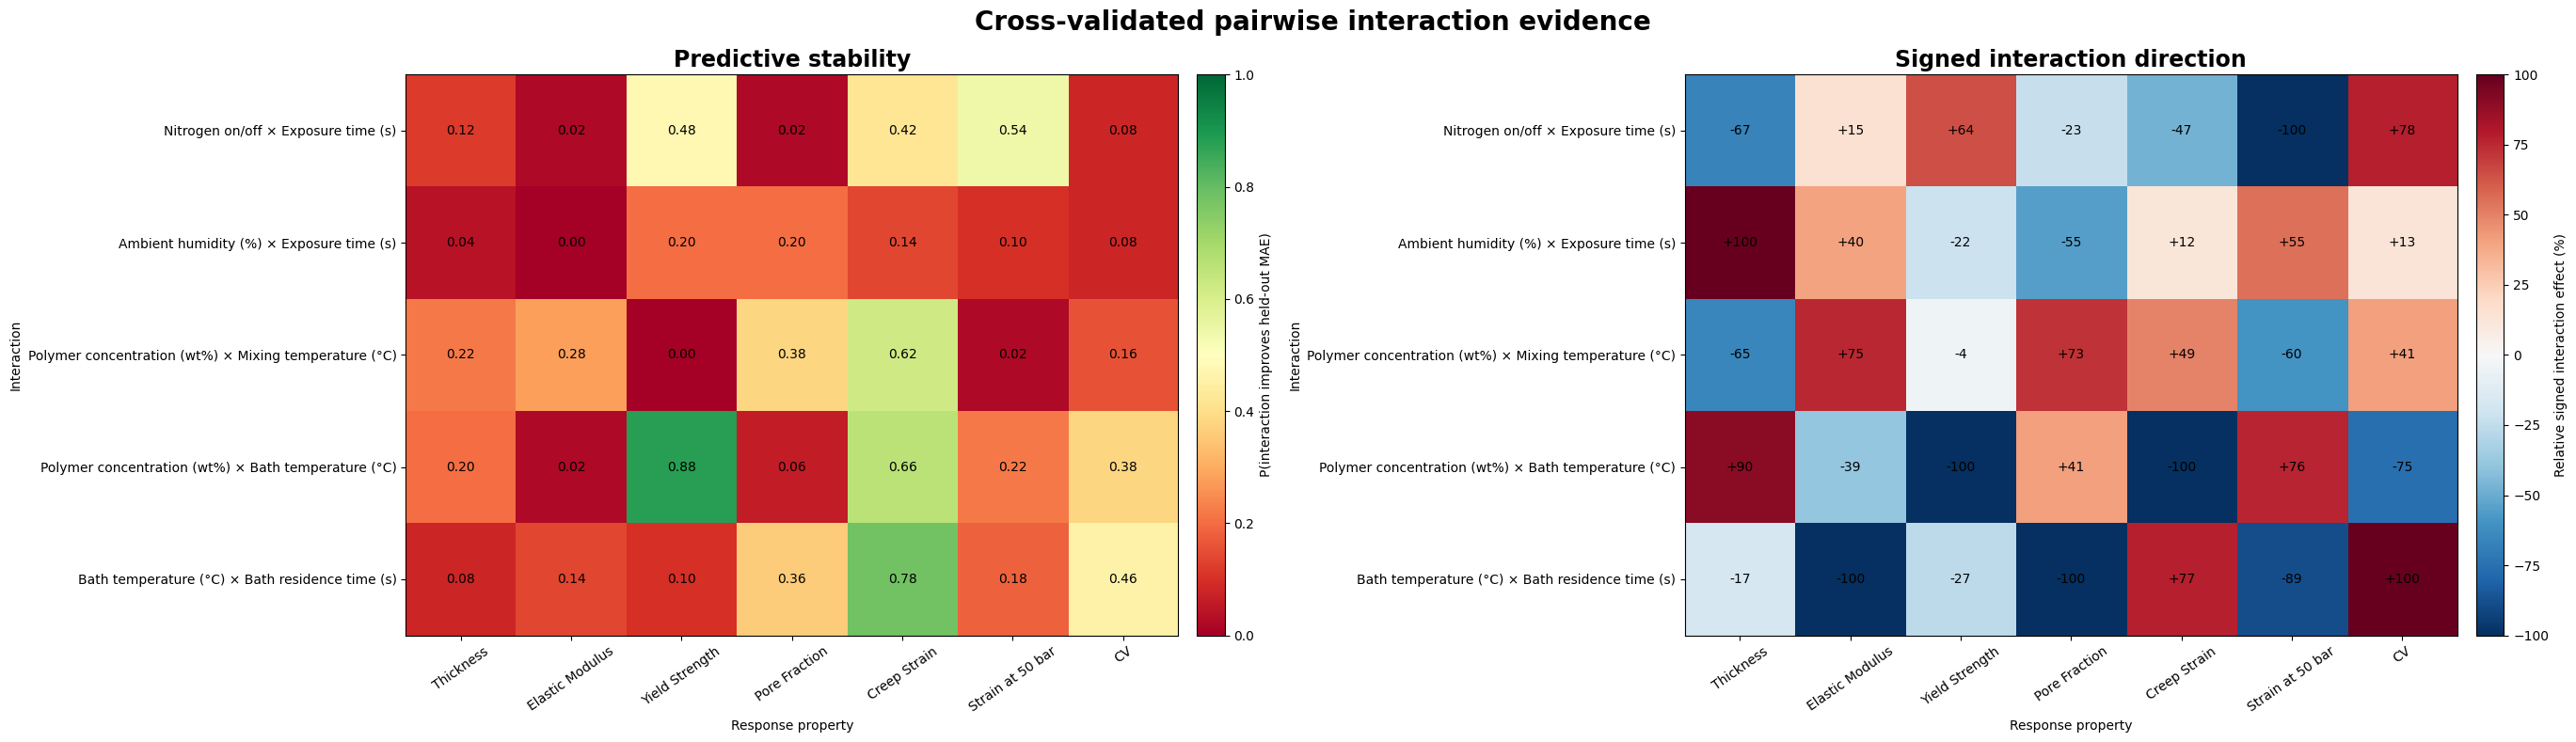

In [59]:
interaction_labels = [f'{INTERACTION_FEATURES[a]} × {INTERACTION_FEATURES[b]}' for a, b in INTERACTION_PAIRS]
interaction_properties = [p for p in FEATURE_IMPORTANCE_PROPERTIES if p in interaction_results.property.unique()]
gain = interaction_results.pivot(index='interaction', columns='property', values='probability_improves').reindex(index=interaction_labels, columns=interaction_properties)
direction = interaction_results.pivot(index='interaction', columns='property', values='interaction_effect_mean').reindex(index=interaction_labels, columns=interaction_properties)
direction = direction.apply(lambda x: 100*x/x.abs().max() if x.abs().max() else x)
figure_interactions, interaction_axes = plt.subplots(1, 2, figsize=(max(18, 4*len(interaction_properties)), 8))
for axis, matrix, cmap, limits, title, label in [(interaction_axes[0], gain, 'RdYlGn', (0,1), 'Predictive stability', 'P(interaction improves held-out MAE)'), (interaction_axes[1], direction, 'RdBu_r', (-100,100), 'Signed interaction direction', 'Relative signed interaction effect (%)')]:
    image = axis.imshow(matrix, cmap=cmap, vmin=limits[0], vmax=limits[1], aspect='auto')
    axis.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=35); axis.set_yticks(range(len(matrix.index)), matrix.index)
    for row in range(len(matrix.index)):
        for column in range(len(matrix.columns)):
            value = matrix.iloc[row, column]; text = f'{value:.2f}' if limits[1] == 1 else f'{value:+.0f}'
            axis.text(column, row, text, ha='center', va='center', fontsize=10)
    axis.set_title(title, fontsize=17, fontweight='semibold'); axis.set_xlabel('Response property'); axis.set_ylabel('Interaction')
    figure_interactions.colorbar(image, ax=axis, pad=.02).set_label(label)
figure_interactions.suptitle('Cross-validated pairwise interaction evidence', fontsize=20, fontweight='semibold')
figure_interactions.tight_layout(); plt.show()

## Linear SHAP analysis

For the standardized ridge model, the SHAP contribution under a mean-background/feature-independence assumption is `(standardized feature value) × (ridge coefficient)`. The contributions are additive: their sum plus the baseline prediction equals the model prediction. Positive values push a predicted property upward; negative values push it downward.

The first figure summarizes global mean absolute SHAP magnitude. It is followed by a signed per-iteration contribution plot for every modeled response; point color indicates the original feature value. These are model explanations, not causal effects. Correlated campaign settings can redistribute attribution among features.

In [60]:
def calculate_linear_shap(data, properties, features=FEATURES):
    shap_records = []
    prediction_records = []
    for property_name in properties:
        target_column = f'{property_name} Mean'
        usable = data.dropna(subset=[target_column]).copy()
        if len(usable) < MIN_TARGET_SAMPLES:
            continue
        X = usable[list(features)].copy()
        X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
        X = X.apply(pd.to_numeric, errors='coerce')
        variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
        X = X[variable_columns]
        medians = X.median()
        X_numeric = X.fillna(medians).to_numpy(dtype=float)
        center, scale = X_numeric.mean(axis=0), X_numeric.std(axis=0)
        scale[scale == 0] = 1
        X_standardized = (X_numeric - center) / scale
        y = pd.to_numeric(usable[target_column], errors='coerce').to_numpy(dtype=float)
        baseline = y.mean()
        coefficients = np.linalg.solve(
            X_standardized.T @ X_standardized + RIDGE_ALPHA * np.eye(X_standardized.shape[1]),
            X_standardized.T @ (y - baseline),
        )
        shap_values = X_standardized * coefficients
        predictions = baseline + shap_values.sum(axis=1)
        for row_position, (_, sample) in enumerate(usable.iterrows()):
            prediction_records.append({
                'property': property_name, 'iteration': sample['iteration'],
                'observed': y[row_position], 'prediction': predictions[row_position],
                'baseline': baseline,
            })
            for feature_position, feature in enumerate(variable_columns):
                shap_records.append({
                    'property': property_name, 'iteration': sample['iteration'],
                    'feature': features[feature], 'feature_column': feature,
                    'feature_value': X_numeric[row_position, feature_position],
                    'shap_value': shap_values[row_position, feature_position],
                })
    return pd.DataFrame(shap_records), pd.DataFrame(prediction_records)

shap_values, shap_predictions = calculate_linear_shap(
    campaign_detailed, FEATURE_IMPORTANCE_PROPERTIES
)
# Numerical check of the additive SHAP identity.
assert np.allclose(
    shap_predictions['prediction'],
    shap_predictions['baseline'] + shap_values.groupby(['property', 'iteration'])['shap_value'].sum().reindex(
        pd.MultiIndex.from_frame(shap_predictions[['property', 'iteration']])
    ).to_numpy(),
)
shap_values.head()

,property,iteration,feature,feature_column,feature_value,shap_value
0,Thickness,1,Polymer concentration (wt%),polymer_wt,17.0,4.176962
1,Thickness,1,Mixing temperature (°C),mixing_temp,25.0,-2.162356
2,Thickness,1,Bath temperature (°C),bath_temp,5.0,-0.349808
3,Thickness,1,Casting speed (mm/s),pullcast_speed,10.0,0.364852
4,Thickness,1,Nitrogen on/off,nitrogen,1.0,0.971460


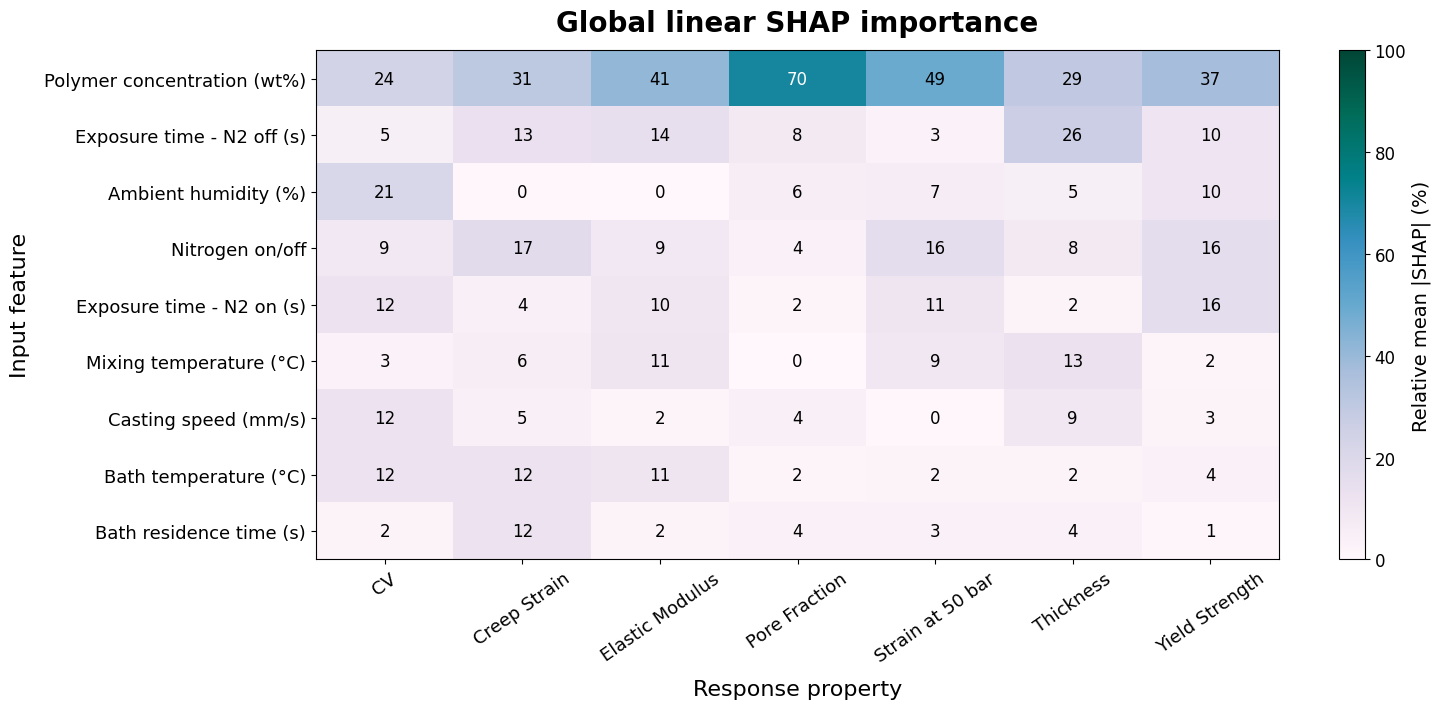

In [61]:
global_shap = (shap_values.assign(abs_shap=lambda frame: frame['shap_value'].abs())
               .groupby(['feature', 'property'], as_index=False)['abs_shap'].mean())
global_shap['relative_mean_abs_shap'] = global_shap.groupby('property')['abs_shap'].transform(
    lambda values: 100 * values / values.sum() if values.sum() > 0 else values
)
shap_matrix = global_shap.pivot(index='feature', columns='property', values='relative_mean_abs_shap').fillna(0)
shap_matrix = shap_matrix.loc[shap_matrix.max(axis=1).sort_values(ascending=False).index]

figure_shap_global, shap_global_axis = plt.subplots(
    figsize=(max(12, 2.2 * len(shap_matrix.columns)), max(7, 0.8 * len(shap_matrix.index)))
)
shap_image = shap_global_axis.imshow(shap_matrix.to_numpy(), cmap='PuBuGn', vmin=0, vmax=100, aspect='auto')
shap_global_axis.set_xticks(range(len(shap_matrix.columns)))
shap_global_axis.set_xticklabels(shap_matrix.columns)
shap_global_axis.set_yticks(range(len(shap_matrix.index)))
shap_global_axis.set_yticklabels(shap_matrix.index)
for row_index in range(len(shap_matrix.index)):
    for column_index in range(len(shap_matrix.columns)):
        value = shap_matrix.iloc[row_index, column_index]
        shap_global_axis.text(column_index, row_index, f'{value:.0f}', ha='center', va='center',
                              fontsize=12, color='white' if value > 55 else 'black')
shap_global_colorbar = figure_shap_global.colorbar(shap_image, ax=shap_global_axis)
shap_global_colorbar.set_label('Relative mean |SHAP| (%)', fontsize=14)
shap_global_colorbar.ax.tick_params(labelsize=12)
shap_global_axis.set_title('Global linear SHAP importance', fontsize=20, fontweight='semibold', pad=14)
shap_global_axis.set_xlabel('Response property', fontsize=16, labelpad=10)
shap_global_axis.set_ylabel('Input feature', fontsize=16, labelpad=10)
shap_global_axis.tick_params(axis='x', labelsize=13, rotation=35)
shap_global_axis.tick_params(axis='y', labelsize=13)
figure_shap_global.tight_layout()
plt.show()

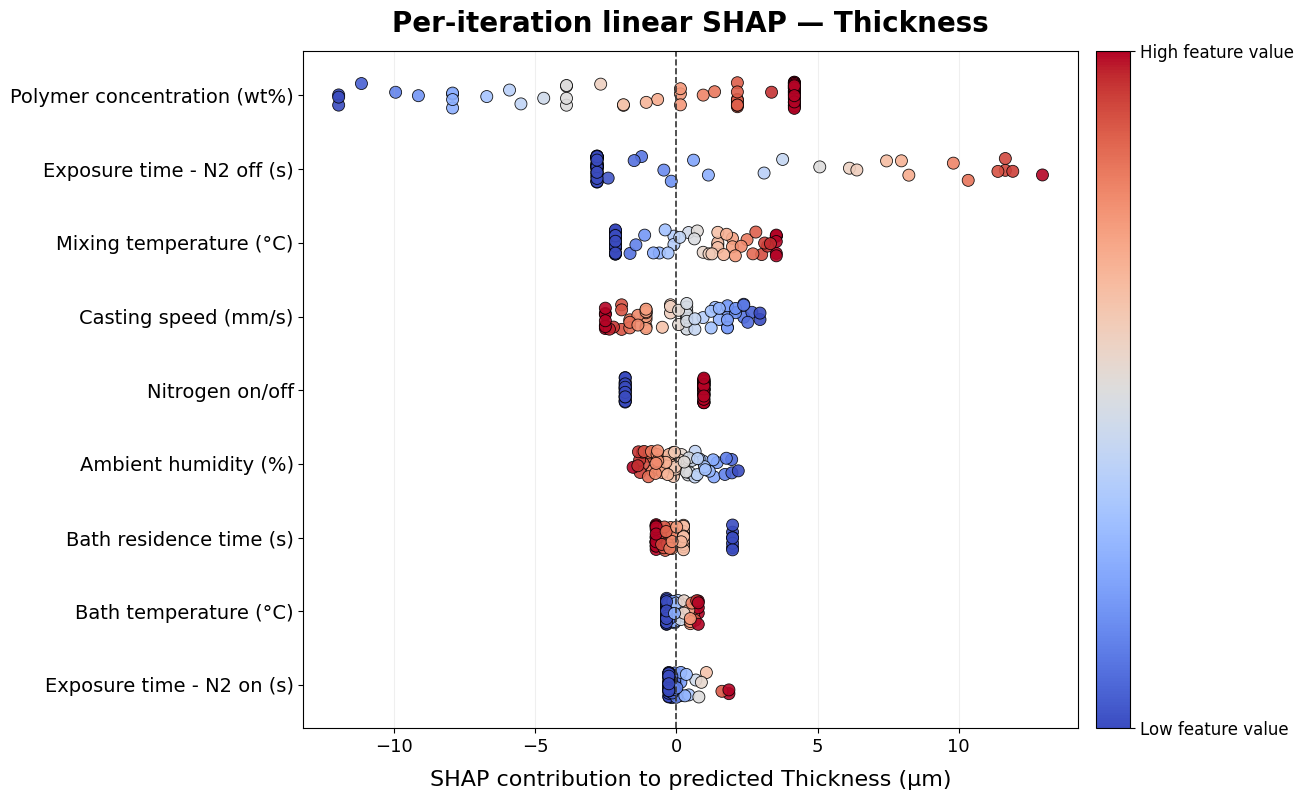

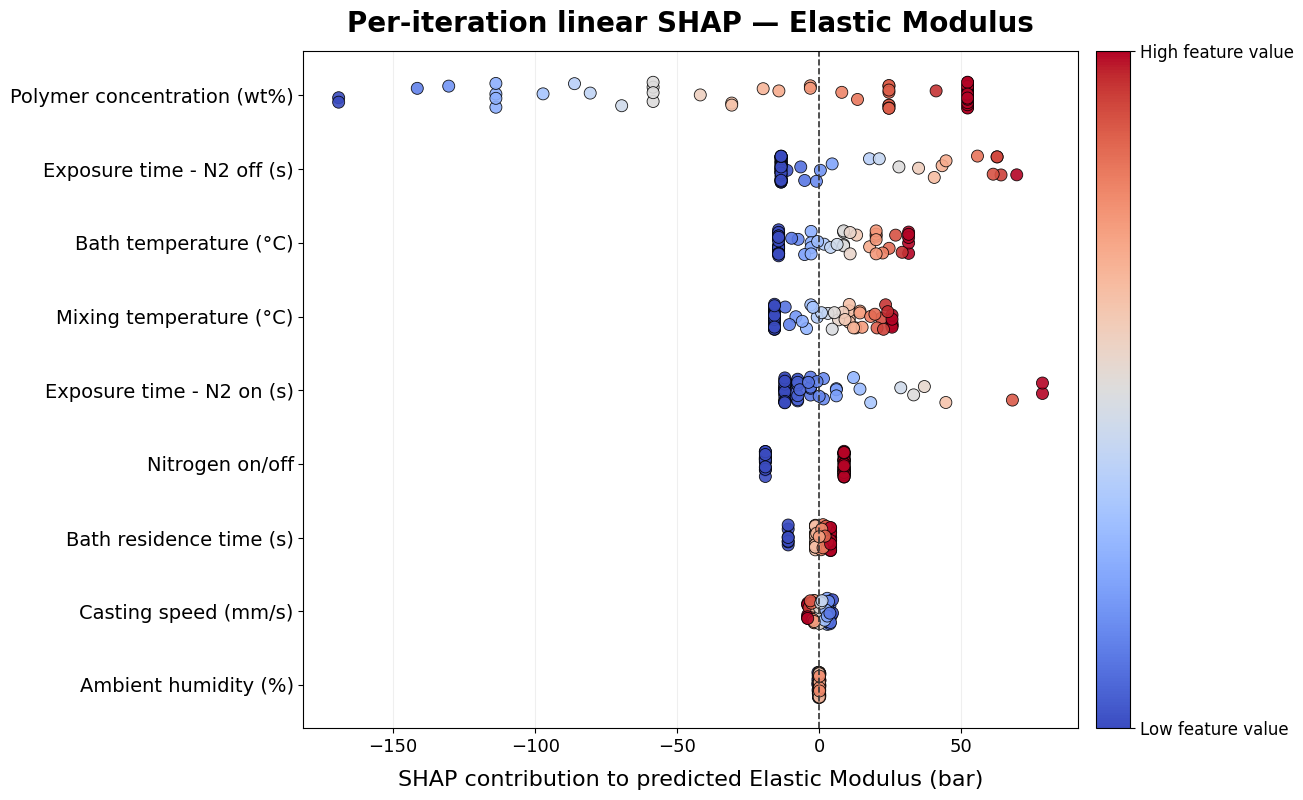

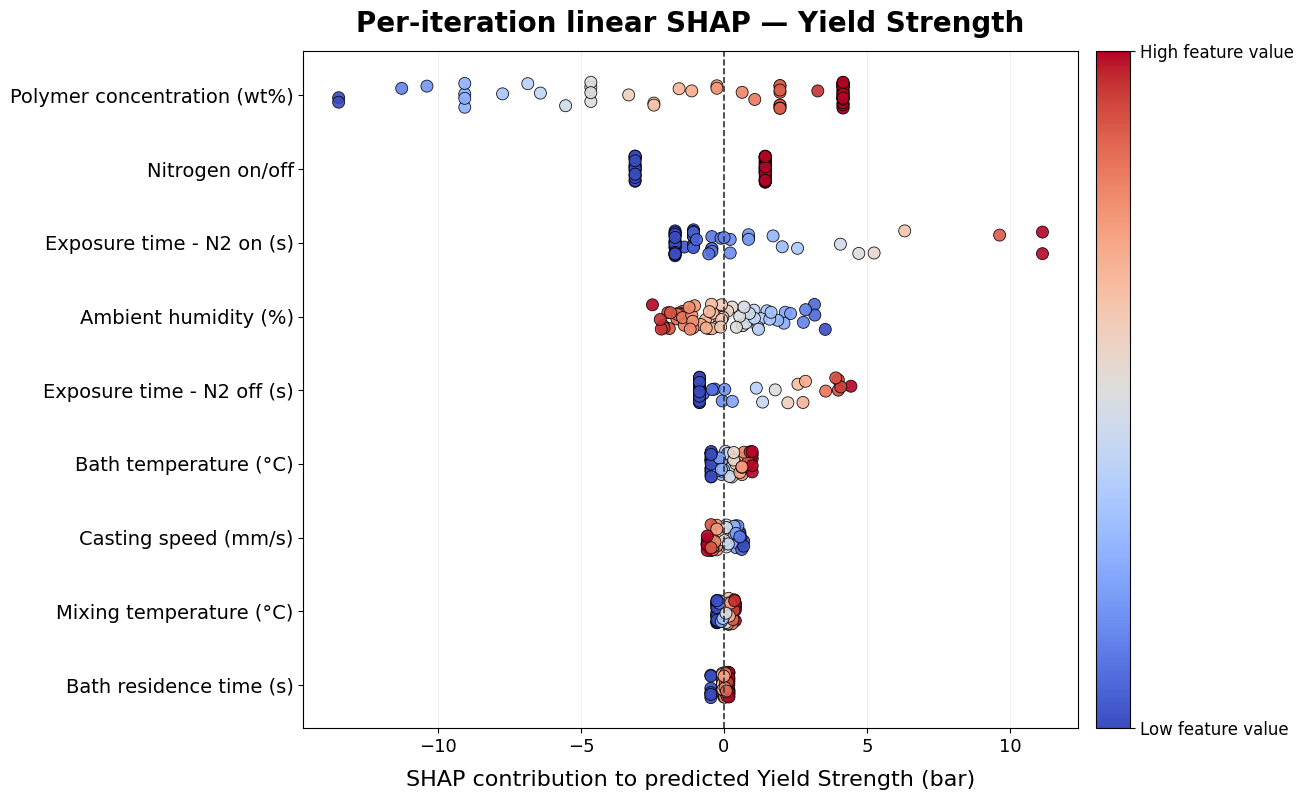

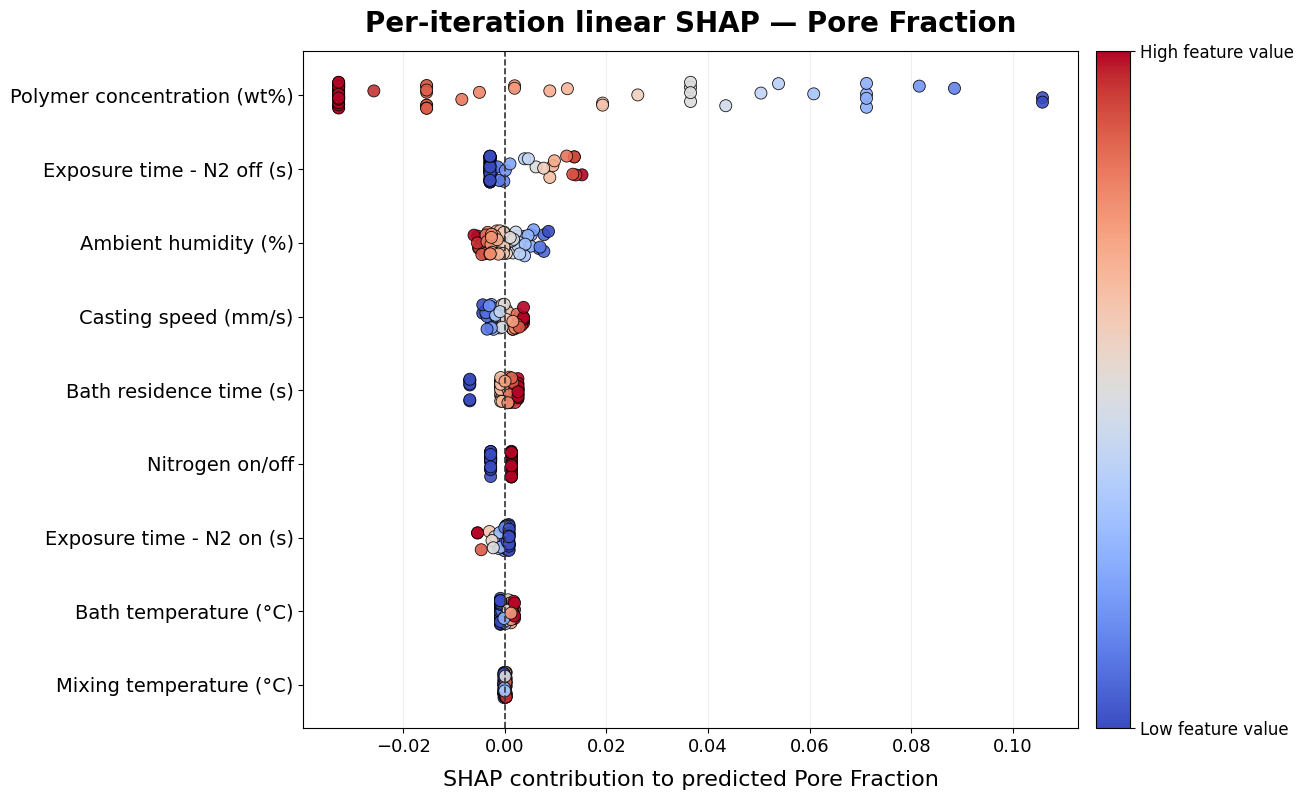

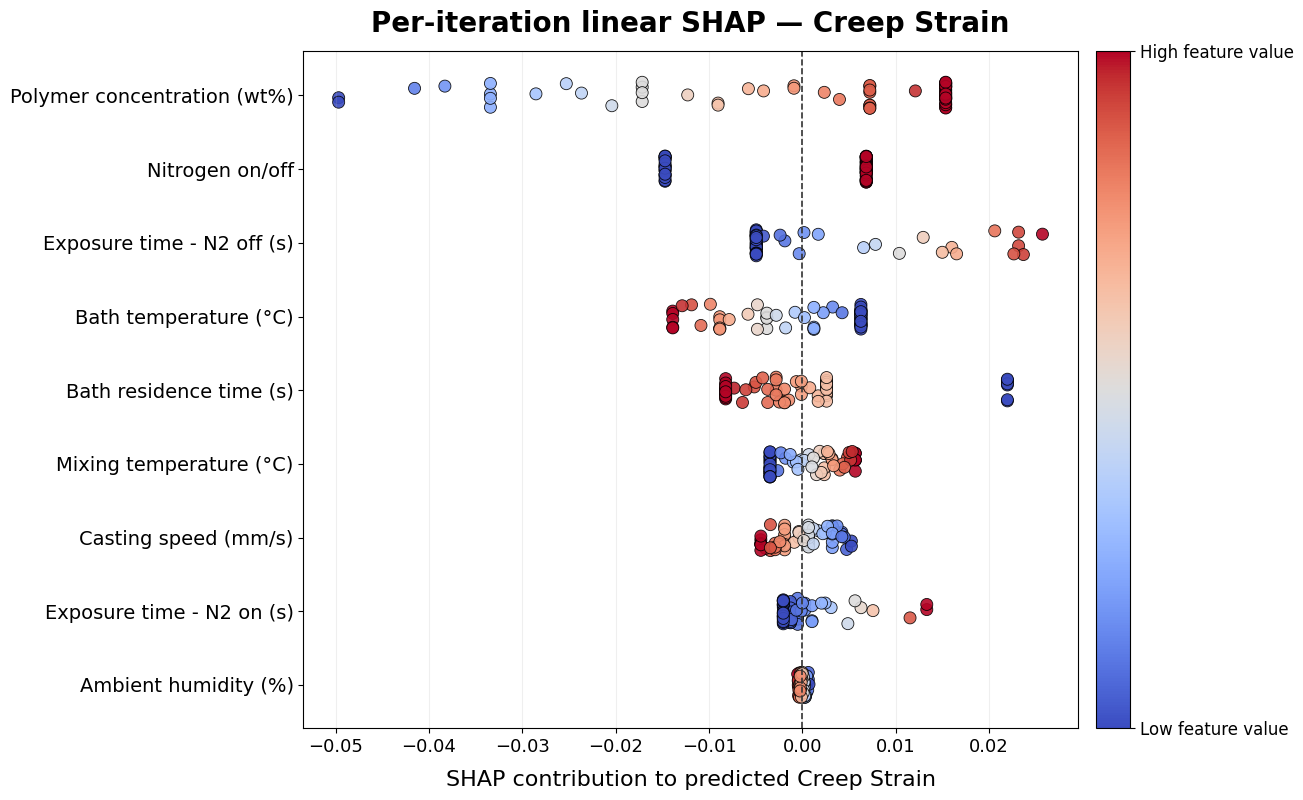

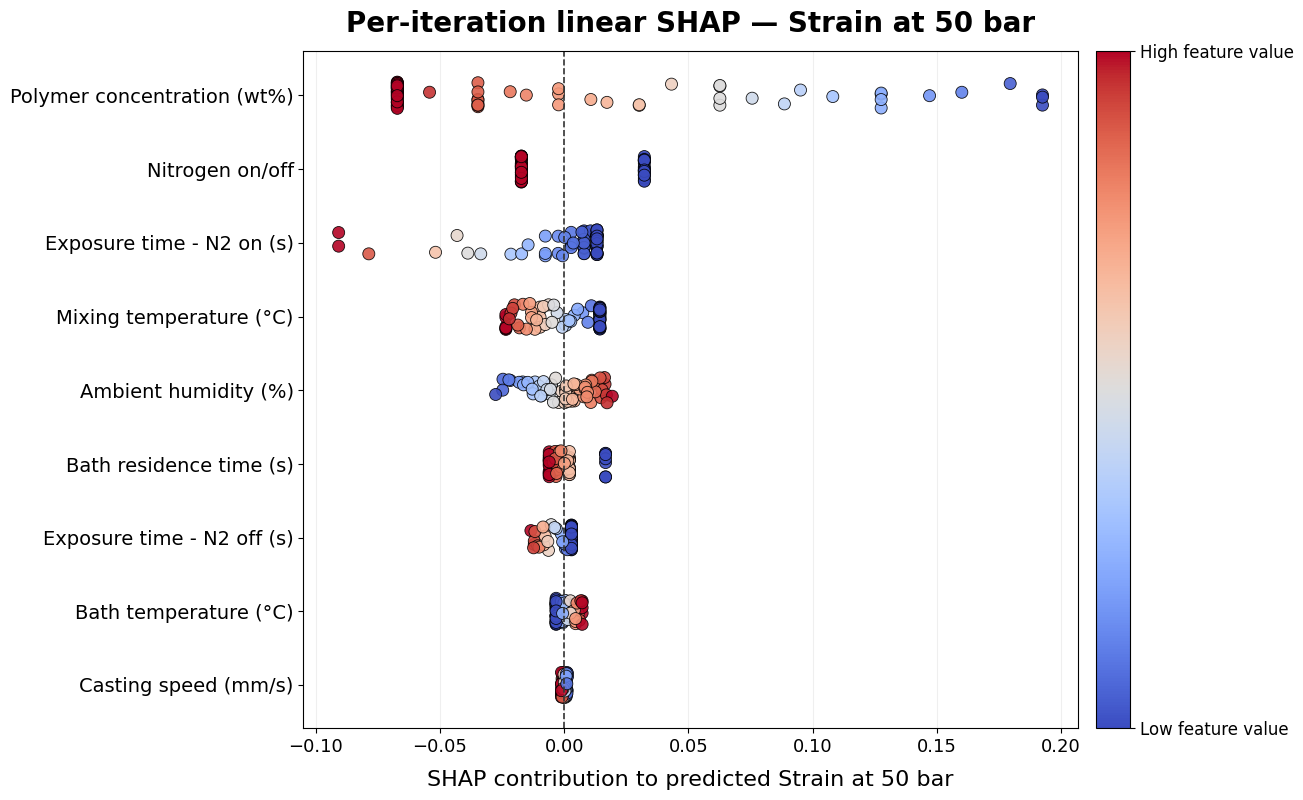

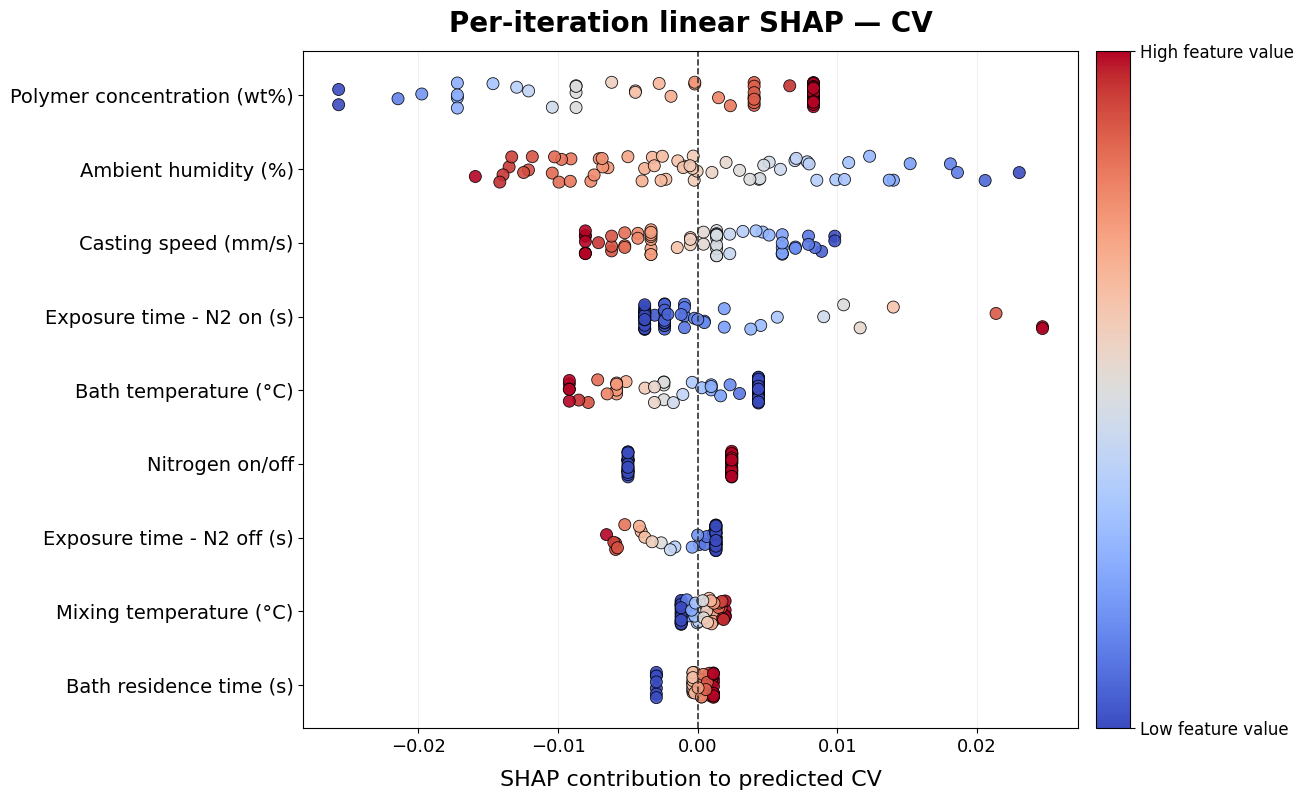

In [62]:
def plot_shap_detail(detail, property_name):
    feature_order = (detail.assign(abs_shap=detail['shap_value'].abs())
                     .groupby('feature')['abs_shap'].mean().sort_values(ascending=True).index.tolist())
    figure, axis = plt.subplots(figsize=(13, max(7, 0.9 * len(feature_order))))
    jitter_generator = np.random.RandomState(RANDOM_STATE)
    for feature_position, feature in enumerate(feature_order):
        feature_points = detail[detail['feature'] == feature].copy()
        values = feature_points['feature_value'].to_numpy(dtype=float)
        value_min, value_max = np.nanmin(values), np.nanmax(values)
        normalized_values = np.full(len(values), 0.5) if value_min == value_max else (values - value_min) / (value_max - value_min)
        vertical_positions = feature_position + jitter_generator.uniform(-0.18, 0.18, len(feature_points))
        axis.scatter(feature_points['shap_value'], vertical_positions, c=normalized_values,
                     cmap='coolwarm', vmin=0, vmax=1, s=75, edgecolor='black', linewidth=0.6, alpha=0.9)
    axis.axvline(0, color='#333333', linestyle='--', linewidth=1.2)
    axis.set_yticks(range(len(feature_order)))
    axis.set_yticklabels(feature_order, fontsize=14)
    axis.set_xlabel(f'SHAP contribution to predicted {property_label(property_name)}', fontsize=16, labelpad=10)
    axis.set_title(f'Per-iteration linear SHAP — {property_name}', fontsize=20, fontweight='semibold', pad=14)
    axis.tick_params(axis='x', labelsize=13)
    axis.grid(axis='x', alpha=0.2)
    color_scale = plt.cm.ScalarMappable(norm=plt.Normalize(0, 1), cmap='coolwarm')
    color_scale.set_array([])
    colorbar = figure.colorbar(color_scale, ax=axis, pad=0.02)
    colorbar.set_ticks([0, 1])
    colorbar.set_ticklabels(['Low feature value', 'High feature value'])
    colorbar.ax.tick_params(labelsize=12)
    figure.tight_layout()
    return figure, axis

figure_shap_details = {}
axes_shap_details = {}
for property_name in FEATURE_IMPORTANCE_PROPERTIES:
    detail = shap_values[shap_values['property'] == property_name].copy()
    if detail.empty:
        continue
    figure_shap_details[property_name], axes_shap_details[property_name] = plot_shap_detail(
        detail, property_name
    )
    plt.show()

## Elastic modulus–pore fraction Pareto frontier

These plots treat **higher Elastic Modulus and higher Pore Fraction as desirable**. A point is Pareto optimal when no other experiment is at least as high on both objectives and strictly higher on at least one. The black dashed line and larger black-framed dots show the observed Pareto frontier; it is a guide through measured non-dominated experiments, not a fitted response curve. Each panel colors the same experiments by one process or environmental parameter. Missing parameter values are gray.

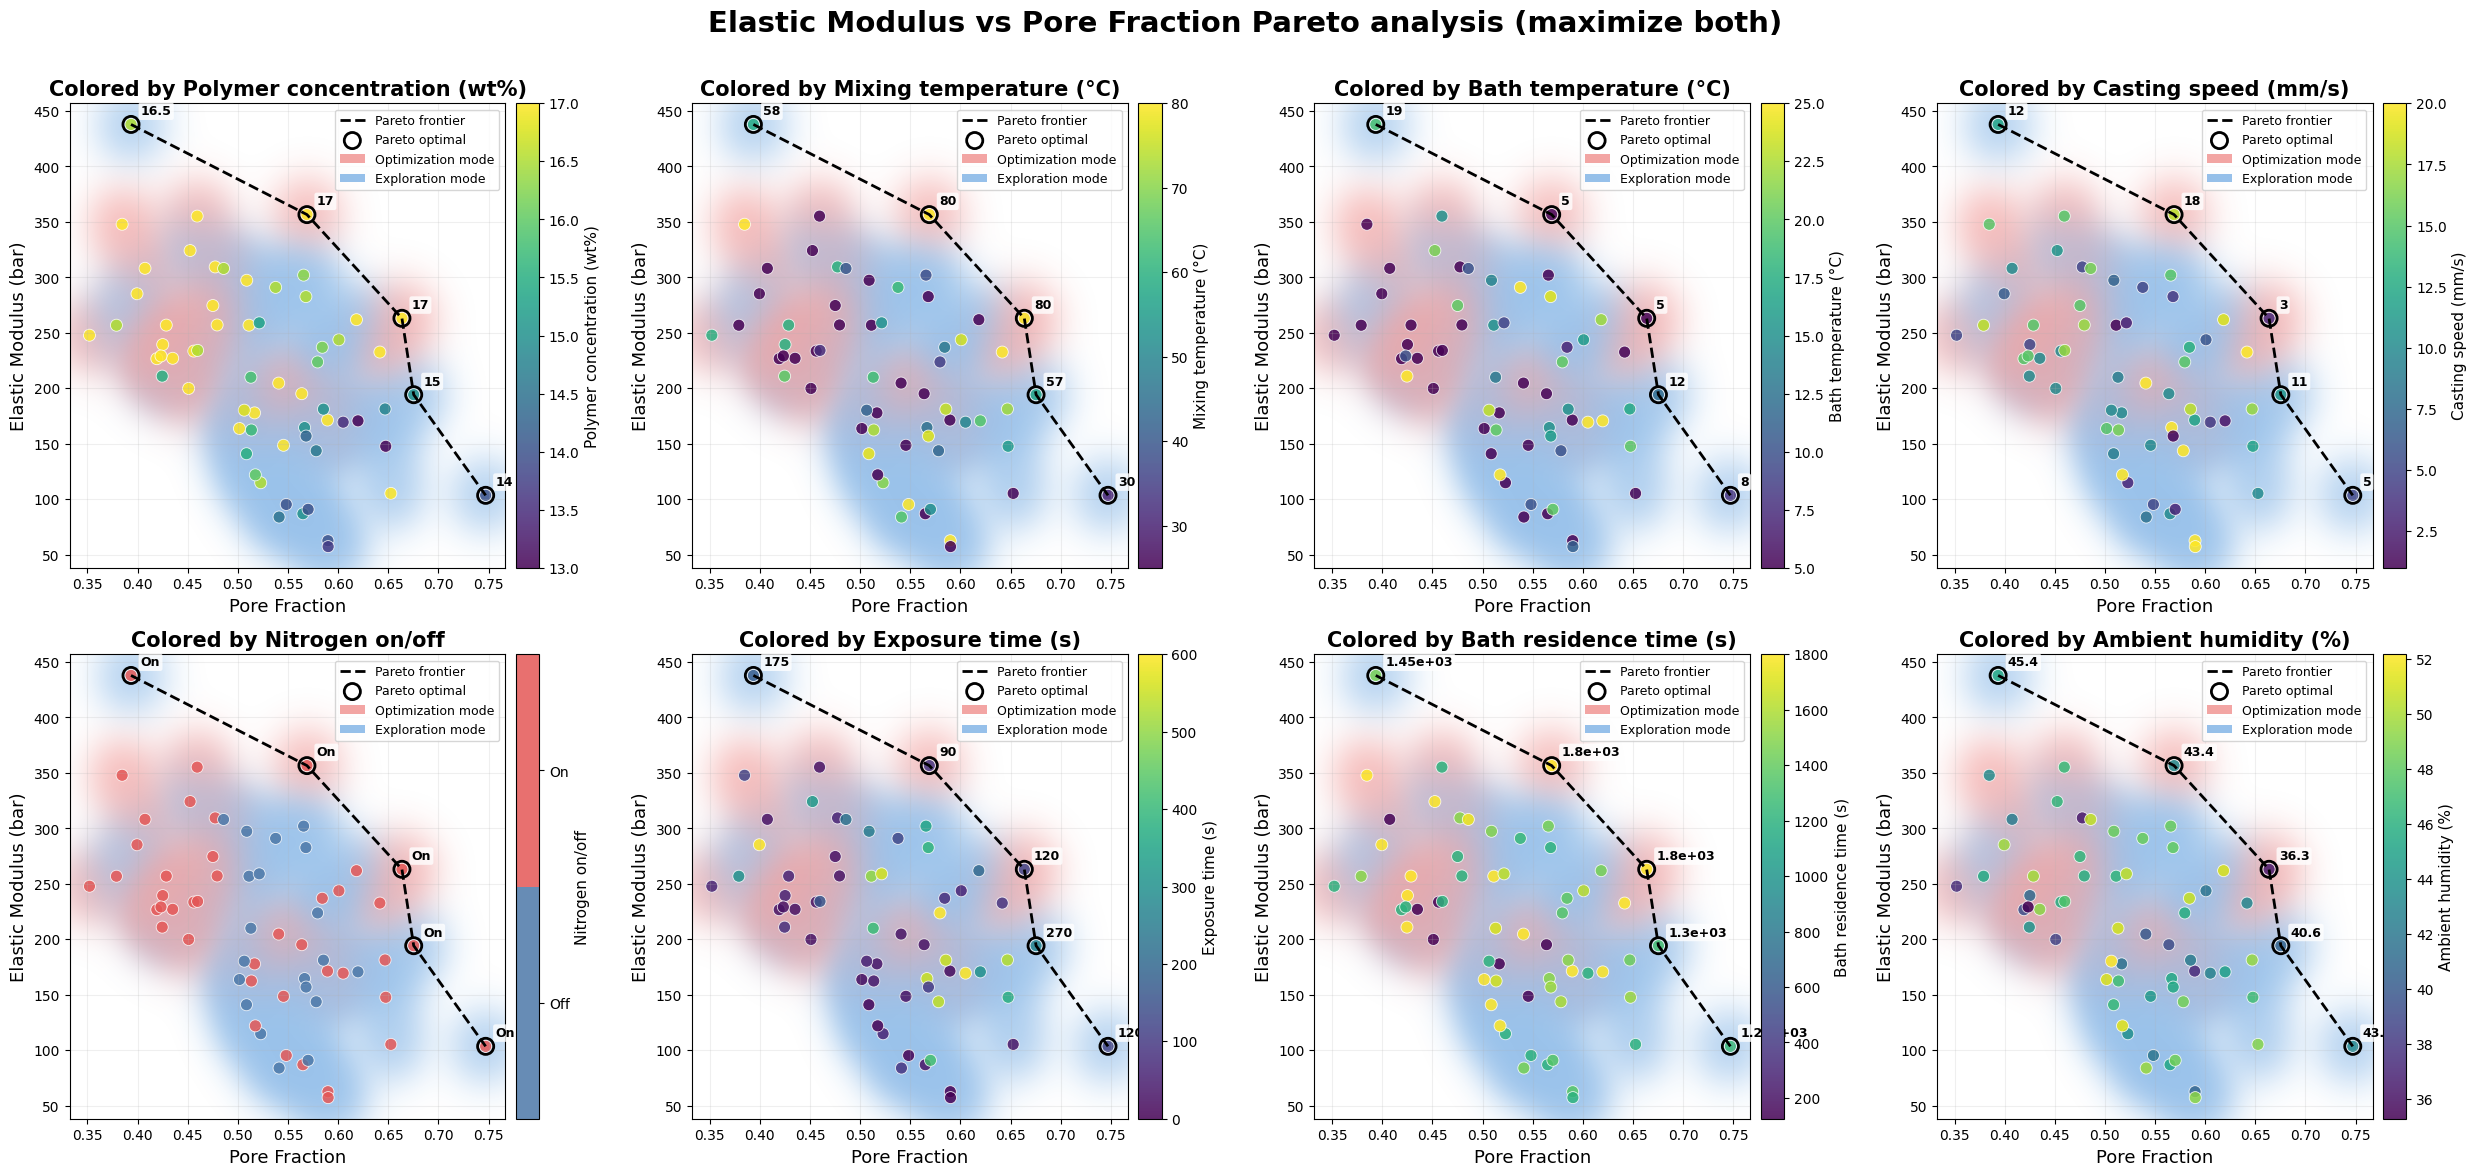

,iteration,Pore Fraction Mean,Elastic Modulus Mean,polymer_wt,mixing_temp,bath_temp,pullcast_speed,nitrogen,coupon_to_bath_wait_time,nips_bath_wait_time,Humidity Mean
53,54,0.393505,437.907553,16.5,58,19,12.0,True,175,1450,45.41
2,3,0.568939,356.645087,17.0,80,5,18.0,True,90,1800,43.37
11,12,0.663672,263.169320,17.0,80,5,3.0,True,120,1800,36.30
38,39,0.675393,194.307651,15.0,57,12,11.0,True,270,1300,40.58
37,38,0.747147,103.601208,14.0,30,8,5.0,True,120,1250,43.22


In [63]:
PARETO_X = 'Pore Fraction Mean'
PARETO_Y = 'Elastic Modulus Mean'
PARETO_HALO_RADIUS = 0.055  # Gaussian width as a fraction of each axis range.
PARETO_HALO_ALPHA = 0.45
PARETO_MODE_COLORS = ['#e53935', '#1976d2']  # Optimization red; exploration blue.
PARETO_PARAMETERS = {
    'polymer_wt': 'Polymer concentration (wt%)',
    'mixing_temp': 'Mixing temperature (°C)',
    'bath_temp': 'Bath temperature (°C)',
    'pullcast_speed': 'Casting speed (mm/s)',
    'nitrogen': 'Nitrogen on/off',
    'coupon_to_bath_wait_time': 'Exposure time (s)',
    'nips_bath_wait_time': 'Bath residence time (s)',
    'Humidity Mean': 'Ambient humidity (%)',
}

def shade_pareto_modes(axis, points):
    """Blend local Gaussian halos; these show campaign mode, not uncertainty."""
    from matplotlib.colors import to_rgb
    from matplotlib.patches import Patch
    xlim, ylim = axis.get_xlim(), axis.get_ylim()
    grid_x, grid_y = np.meshgrid(np.linspace(0, 1, 300), np.linspace(0, 1, 300))
    total = np.zeros_like(grid_x)
    colors = np.zeros(grid_x.shape + (3,))
    handles = []
    for phase, label, color in zip(PHASES, ['Optimization mode', 'Exploration mode'], PARETO_MODE_COLORS):
        mask = points['sample_time'].notna()
        if phase['start'] is not None:
            mask &= points['sample_time'] >= pd.Timestamp(phase['start'])
        if phase['end'] is not None:
            mask &= points['sample_time'] < pd.Timestamp(phase['end'])
        density = np.zeros_like(grid_x)
        for x, y in points.loc[mask, [PARETO_X, PARETO_Y]].to_numpy():
            x = (x - xlim[0]) / (xlim[1] - xlim[0])
            y = (y - ylim[0]) / (ylim[1] - ylim[0])
            density += np.exp(-((grid_x - x)**2 + (grid_y - y)**2) / (2 * PARETO_HALO_RADIUS**2))
        total += density
        colors += density[..., None] * np.asarray(to_rgb(color))
        if mask.any():
            handles.append(Patch(facecolor=color, alpha=PARETO_HALO_ALPHA, label=label))
    rgba = np.zeros(grid_x.shape + (4,))
    rgba[..., :3] = colors / np.maximum(total[..., None], 1e-12)
    rgba[..., 3] = PARETO_HALO_ALPHA * (1 - np.exp(-total))
    axis.imshow(rgba, extent=(*xlim, *ylim), origin='lower', aspect='auto',
                interpolation='bilinear', zorder=0)
    axis.set_xlim(xlim)
    axis.set_ylim(ylim)
    return handles

def pareto_maximize_mask(values):
    """Return non-dominated rows when every column is maximized."""
    values = np.asarray(values, dtype=float)
    is_pareto = np.ones(len(values), dtype=bool)
    for row_index, point in enumerate(values):
        dominates = np.all(values >= point, axis=1) & np.any(values > point, axis=1)
        is_pareto[row_index] = not dominates.any()
    return is_pareto

pareto_data = campaign_detailed.dropna(subset=[PARETO_X, PARETO_Y]).copy()
pareto_data[PARETO_X] = pd.to_numeric(pareto_data[PARETO_X], errors='coerce')
pareto_data[PARETO_Y] = pd.to_numeric(pareto_data[PARETO_Y], errors='coerce')
pareto_data = pareto_data.dropna(subset=[PARETO_X, PARETO_Y])
pareto_data['pareto_optimal'] = pareto_maximize_mask(pareto_data[[PARETO_X, PARETO_Y]].to_numpy())
pareto_frontier = pareto_data[pareto_data['pareto_optimal']].sort_values(PARETO_X)

def plot_pareto_campaign(*, with_halo=True):
    n_columns = 4
    n_rows = 2
    figure_pareto, axes_pareto = plt.subplots(n_rows, n_columns, figsize=(25, 11.6), squeeze=False)
    for axis, (parameter, parameter_label) in zip(axes_pareto.flat, PARETO_PARAMETERS.items()):
        if parameter == 'nitrogen':
            color_values = pareto_data[parameter].map(nitrogen_to_binary).astype(float)
            scatter = axis.scatter(pareto_data[PARETO_X], pareto_data[PARETO_Y], c=color_values,
                                   cmap=plt.matplotlib.colors.ListedColormap(['#4C78A8', '#E45756']),
                                   vmin=-0.5, vmax=1.5, s=75, alpha=0.85, edgecolor='white', linewidth=0.6)
            colorbar = figure_pareto.colorbar(scatter, ax=axis, ticks=[0, 1], pad=0.02)
            colorbar.ax.set_yticklabels(['Off', 'On'])
        else:
            color_values = pd.to_numeric(pareto_data[parameter], errors='coerce')
            valid_color = color_values.notna()
            if (~valid_color).any():
                axis.scatter(pareto_data.loc[~valid_color, PARETO_X], pareto_data.loc[~valid_color, PARETO_Y],
                             color='#BDBDBD', s=75, alpha=0.7, edgecolor='white', linewidth=0.6)
            scatter = axis.scatter(pareto_data.loc[valid_color, PARETO_X], pareto_data.loc[valid_color, PARETO_Y],
                                   c=color_values[valid_color], cmap='viridis', s=75, alpha=0.85,
                                   edgecolor='white', linewidth=0.6)
            colorbar = figure_pareto.colorbar(scatter, ax=axis, pad=0.02)
        colorbar.set_label(parameter_label, fontsize=11)
        axis.plot(pareto_frontier[PARETO_X], pareto_frontier[PARETO_Y], 'k--', linewidth=2.0,
                  label='Pareto frontier', zorder=4)
        axis.scatter(pareto_frontier[PARETO_X], pareto_frontier[PARETO_Y], marker='o', s=135,
                     facecolor='none', edgecolor='black', linewidth=2.0, label='Pareto optimal', zorder=5)
        for _, frontier_point in pareto_frontier.iterrows():
            if parameter == 'nitrogen':
                value_label = 'On' if nitrogen_to_binary(frontier_point[parameter]) else 'Off'
            else:
                parameter_value = pd.to_numeric(frontier_point[parameter], errors='coerce')
                value_label = 'NA' if pd.isna(parameter_value) else f'{parameter_value:.3g}'
            axis.annotate(value_label, (frontier_point[PARETO_X], frontier_point[PARETO_Y]),
                          xytext=(7, 7), textcoords='offset points', fontsize=9, fontweight='semibold',
                          color='black', bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                                                   edgecolor='none', alpha=0.78), zorder=6)
        axis.set_title(f'Colored by {parameter_label}', fontsize=15, fontweight='semibold')
        axis.set_xlabel(property_label('Pore Fraction'), fontsize=13)
        axis.set_ylabel(property_label('Elastic Modulus'), fontsize=13)
        axis.grid(alpha=0.2)
        mode_handles = shade_pareto_modes(axis, pareto_data) if with_halo else []
        handles, labels = axis.get_legend_handles_labels()
        axis.legend(handles=handles + mode_handles, loc='best', fontsize=9)
    for axis in axes_pareto.flat[len(PARETO_PARAMETERS):]:
        axis.set_visible(False)
    figure_pareto.suptitle('Elastic Modulus vs Pore Fraction Pareto analysis (maximize both)',
                           fontsize=21, fontweight='semibold', y=1.01)
    figure_pareto.tight_layout()
    return figure_pareto, axes_pareto

# Version 1: campaign-mode halos (red optimization, blue exploration).
figure_pareto, axes_pareto = plot_pareto_campaign(with_halo=True)
plt.show()

pareto_data.loc[pareto_data['pareto_optimal'],
                ['iteration', PARETO_X, PARETO_Y] + list(PARETO_PARAMETERS)].sort_values(PARETO_X)

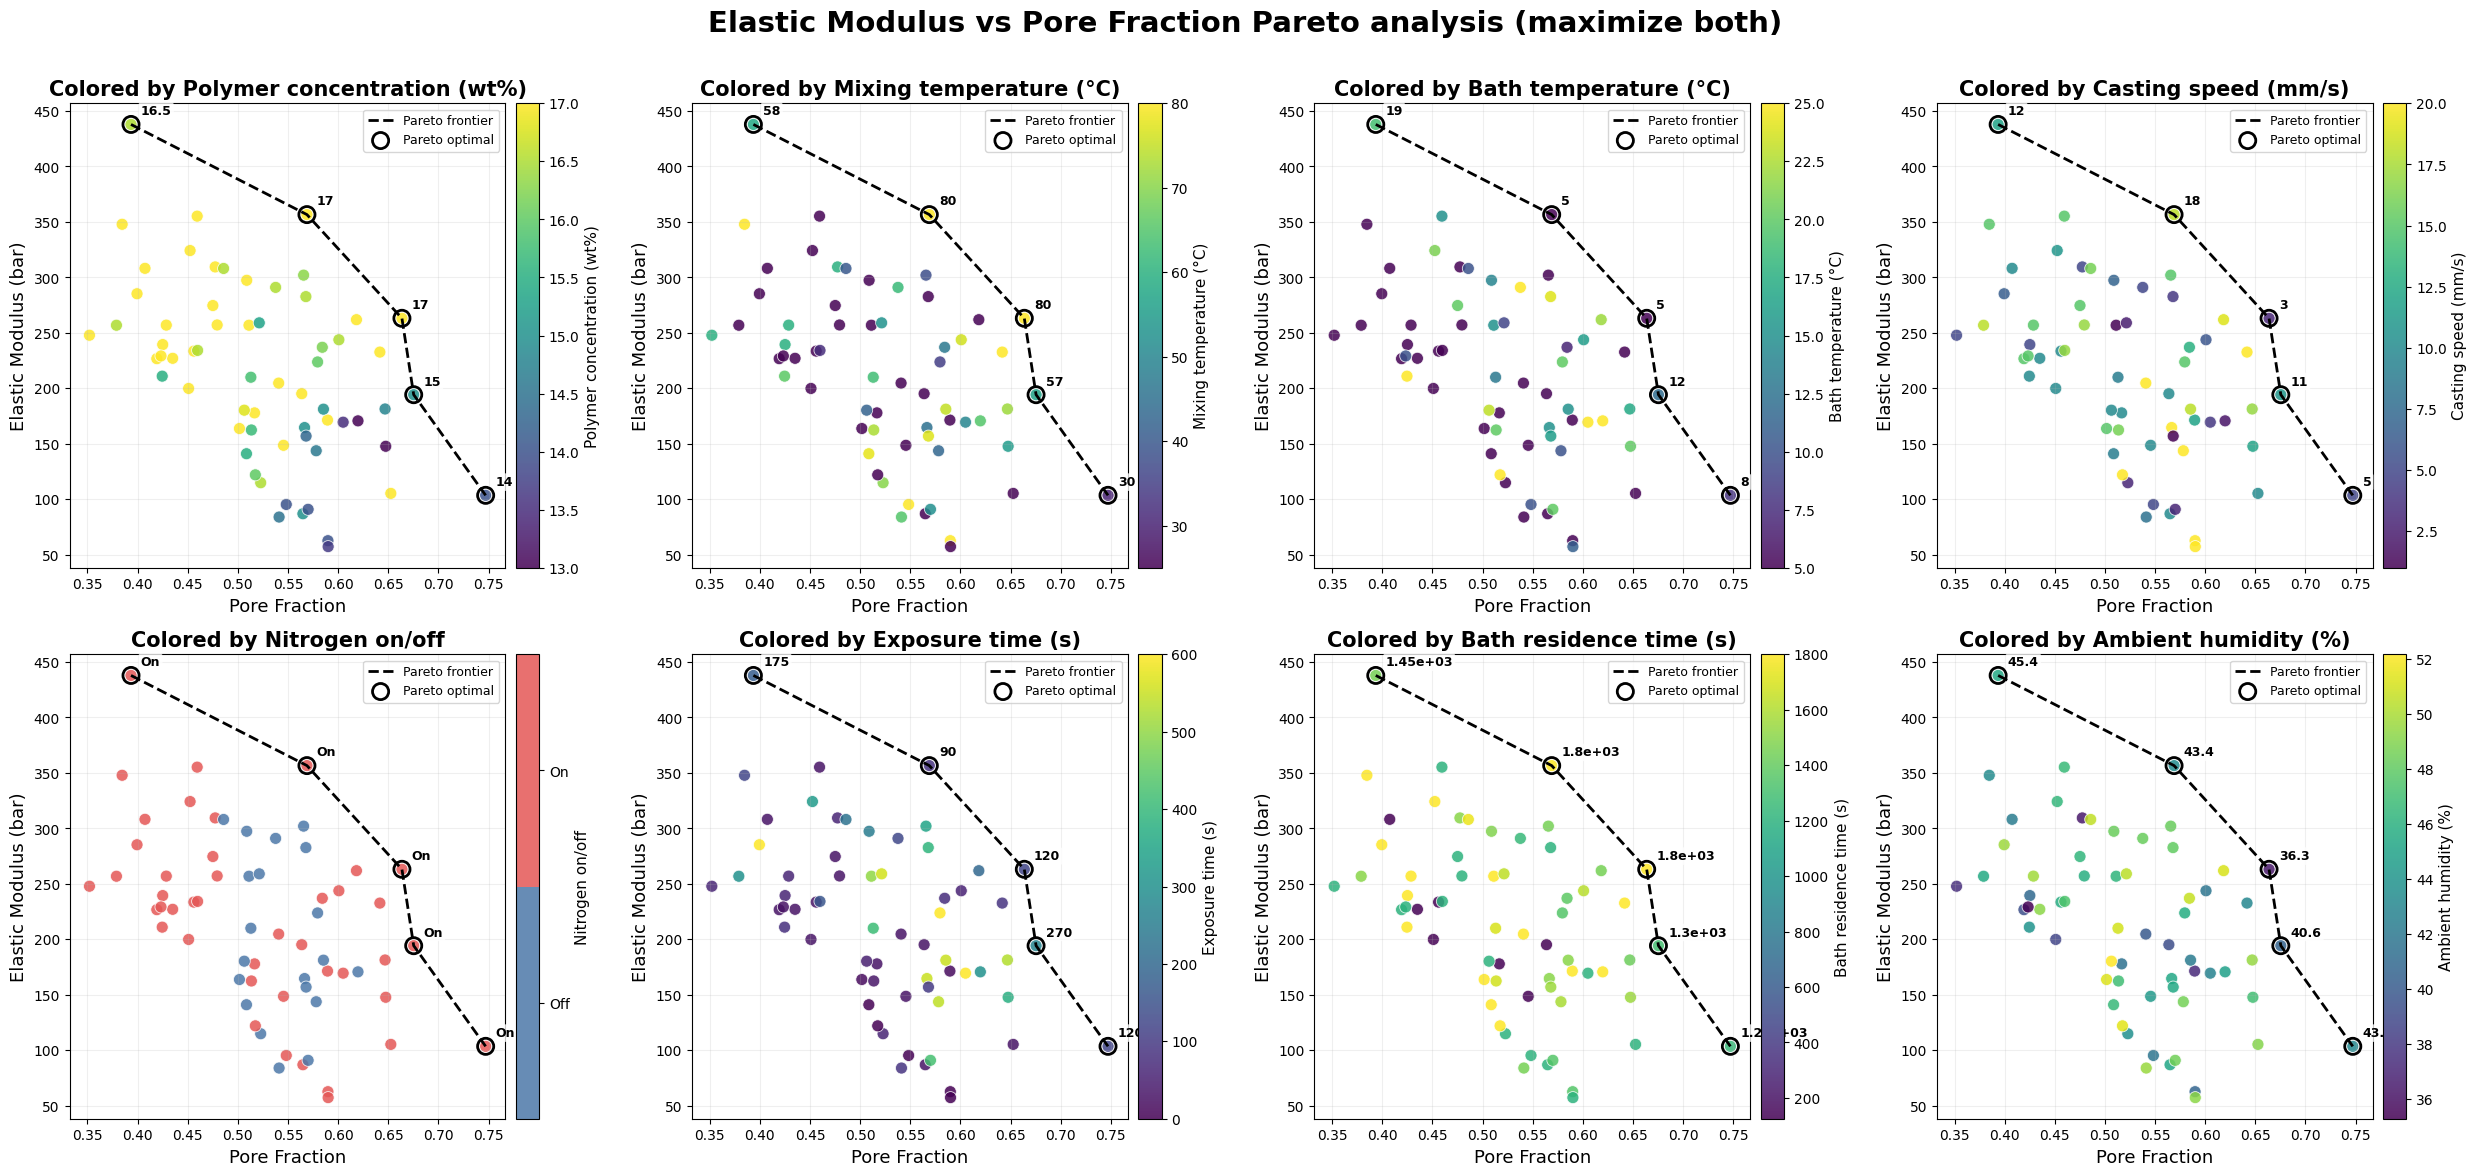

In [64]:
# Version 2: the same Pareto plots without halos.
figure_pareto_no_halo, axes_pareto_no_halo = plot_pareto_campaign(with_halo=False)
plt.show()


In [65]:
# Optional explicit export of the enhanced figure/data; nothing is written otherwise.
if SAVE_OUTPUTS:
    output_dir = repo_root / 'EVALUATE' / 'campaign_trends_output'
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / 'campaign_data_detailed.csv'
    polymer_png = output_dir / 'campaign_properties_by_polymer.png'
    humidity_png = output_dir / 'campaign_properties_by_humidity_nitrogen.png'
    exposure_png = output_dir / 'campaign_properties_by_exposure_time.png'
    bath_png = output_dir / 'campaign_properties_by_bath_temperature.png'
    casting_png = output_dir / 'campaign_properties_by_casting_speed.png'
    importance_csv = output_dir / 'campaign_feature_importance.csv'
    importance_png = output_dir / 'campaign_feature_importance.png'
    importance_confidence_png = output_dir / 'campaign_feature_importance_confidence.png'
    importance_direction_png = output_dir / 'campaign_feature_importance_direction.png'
    nitrogen_exposure_png = output_dir / 'campaign_nitrogen_exposure_surfaces.png'
    humidity_exposure_png = output_dir / 'campaign_humidity_exposure_surfaces.png'
    shap_values_csv = output_dir / 'campaign_linear_shap_values.csv'
    shap_predictions_csv = output_dir / 'campaign_linear_shap_predictions.csv'
    shap_global_png = output_dir / 'campaign_linear_shap_global.png'
    pareto_csv = output_dir / 'elastic_modulus_pore_fraction_pareto.csv'
    pareto_png = output_dir / 'elastic_modulus_pore_fraction_pareto_by_parameter.png'
    pareto_no_halo_png = output_dir / 'elastic_modulus_pore_fraction_pareto_by_parameter_no_halo.png'
    interaction_csv = output_dir / 'campaign_pairwise_interactions.csv'
    interaction_png = output_dir / 'campaign_pairwise_interactions.png'
    campaign_detailed.to_csv(csv_path, index=False)
    figure_polymer.savefig(polymer_png, dpi=180, bbox_inches='tight')
    figure_humidity.savefig(humidity_png, dpi=180, bbox_inches='tight')
    figure_exposure.savefig(exposure_png, dpi=180, bbox_inches='tight')
    figure_bath.savefig(bath_png, dpi=180, bbox_inches='tight')
    figure_casting.savefig(casting_png, dpi=180, bbox_inches='tight')
    feature_importance.to_csv(importance_csv, index=False)
    figure_importance.savefig(importance_png, dpi=180, bbox_inches='tight')
    figure_importance_confidence.savefig(importance_confidence_png, dpi=180, bbox_inches='tight')
    figure_importance_direction.savefig(importance_direction_png, dpi=180, bbox_inches='tight')
    figure_nitrogen_exposure.savefig(nitrogen_exposure_png, dpi=180, bbox_inches='tight')
    figure_humidity_exposure.savefig(humidity_exposure_png, dpi=180, bbox_inches='tight')
    shap_values.to_csv(shap_values_csv, index=False)
    shap_predictions.to_csv(shap_predictions_csv, index=False)
    figure_shap_global.savefig(shap_global_png, dpi=180, bbox_inches='tight')
    pareto_data.to_csv(pareto_csv, index=False)
    figure_pareto.savefig(pareto_png, dpi=180, bbox_inches='tight')
    figure_pareto_no_halo.savefig(pareto_no_halo_png, dpi=180, bbox_inches='tight')
    interaction_results.to_csv(interaction_csv, index=False)
    figure_interactions.savefig(interaction_png, dpi=180, bbox_inches='tight')
    shap_detail_paths = []
    for property_name, detail_figure in figure_shap_details.items():
        safe_property = property_name.lower().replace(' ', '_')
        detail_path = output_dir / f'campaign_linear_shap_{safe_property}.png'
        detail_figure.savefig(detail_path, dpi=180, bbox_inches='tight')
        shap_detail_paths.append(detail_path)
    all_saved_paths = [csv_path, polymer_png, humidity_png, exposure_png, bath_png, casting_png,
                       importance_csv, importance_png, importance_confidence_png, importance_direction_png,
                       nitrogen_exposure_png, humidity_exposure_png,
                       shap_values_csv, shap_predictions_csv,
                       shap_global_png, pareto_csv, pareto_png, pareto_no_halo_png, interaction_csv, interaction_png] + shap_detail_paths
    print('Saved ' + '\nSaved '.join(str(path) for path in all_saved_paths))